# Delta-k and White-Noise Turbulence Models

Study of all four spectral models derived in `derivation.tex` (§ *Monochromatic and White-Noise Spectra*).

| # | Spatial model | Temporal model | Remaining integrals |
|---|---|---|---|
| 1 | $E(k)=E_0\delta(k-k_0)$ | Kraichnan (Gaussian) | **none** — fully closed form |
| 2 | $E(k)=E_0\delta(k-k_0)$ | Decay ($g$-kernel) | 1-D temporal convolution |
| 3 | $R\propto\delta^3(\mathbf{r})$ (white noise) | Kraichnan | 2-D spatial integral |
| 4 | $R\propto\delta^3(\mathbf{r})$ (white noise) | Decay ($g$-kernel) | 2-D spatial $\times$ 1-D temporal |

All quantities are **dimensionless**: $p=k/k_0$, $\Omega=\omega/\eta_0$ (Kraichnan), $q=\omega\tau_1$ (decay).

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import optimize

sys.path.insert(0, os.path.abspath('..'))
from gw_turbulence import (
    K0_p,
    H_delta_k_kraichnan, H_delta_k_kraichnan_grid,
    H_delta_k_decay,    H_delta_k_decay_grid,
    kernel_bracket_zy,
    H_white_kraichnan,  H_white_kraichnan_grid,
    H_white_decay,      H_white_decay_grid,
    g_decaying, LiveStatusLogger,
)

%matplotlib inline
plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 13,
    'legend.fontsize': 10, 'lines.linewidth': 2.0,
    'savefig.dpi': 150,
})

out_dir = os.path.abspath('outputs')
os.makedirs(out_dir, exist_ok=True)
print(f'Output directory: {out_dir}')

Output directory: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs


## Parameter and integration-bounds dictionaries

We define all physics parameters here so every later cell just references them.

In [2]:
R_WHITE = 100.0              # dynamic range k_d/k_0 for white-noise models
Rd34    = R_WHITE ** 0.75   # = (k_d/k_0)^{3/4}  (upper bound on z and y)

# ── Integration bounds dictionaries ─────────────────────────────────────────
# Filled analytically here; numerical peak locations appended as we compute.
bounds_dict = {
    'delta_k_kraichnan': {
        'p_range'         : (0.0, 2.0),
        'Omega_range'     : (0.0, float('inf')),
        'constraint_p'    : 'p <= 2  from triangle inequality |k-k0| <= k0 <= k+k0',
        'constraint_Omega': 'Gaussian exp(-Omega^2/(2*pi)); no hard cutoff in frequency',
        'K0_max_at_p'     : float(np.sqrt(2.0)),
        'K0_max_value'    : float(K0_p(np.sqrt(2.0))),
    },
    'delta_k_decay': {
        'p_range'         : (0.0, 2.0),
        'q_range'         : (0.0, float('inf')),
        'q1_integration'  : 'q1 in [-q_bound, q_bound] with small windows removed around q1=0 and q1=q',
        'q_bound_formula' : 'q_bound = max(|q| + 20, 30)',
        'constraint_p'    : 'p <= 2  (same triangle inequality)',
    },
    'white_kraichnan': {
        'R'              : R_WHITE,
        'Rd34'           : Rd34,
        'z_range'        : (1.0, Rd34),
        'y_range_formula': 'max(|p-z|, 1) <= y <= min(p+z, Rd34)',
        'Omega_range'    : (0.0, float('inf')),
        'p_support'      : (0.0, 2.0 * Rd34),
        'constraint_z'   : 'z in [1, R^{3/4}]  (inertial range for k_1)',
        'constraint_y'   : 'triangle inequality + inertial-range cut for u=|k-k1|',
        'note_p_cutoff'  : 'S(p)=0 for p > 2*Rd34 because y_lo > Rd34 for all z in [1,Rd34]',
    },
    'white_decay': {
        'R'              : R_WHITE,
        'Rd34'           : Rd34,
        'z_range'        : (1.0, Rd34),
        'y_range_formula': 'max(|p-z|, 1) <= y <= min(p+z, Rd34)',
        'q1_integration' : 'q1 in [-q_bound, q_bound] with small windows removed around q1=0 and q1=q',
        'p_support'      : (0.0, 2.0 * Rd34),
        'note'           : 'Spatial and temporal factors fully separable; computed independently',
    },
}

# ── Peaks dictionary — filled progressively throughout the notebook ──────────
peaks_dict = {}

print(f'R = {R_WHITE},  R^{{3/4}} = {Rd34:.3f}')
print(f'K0 maximum: K0(sqrt(2)) = {K0_p(np.sqrt(2.0)):.4f}  at  p = sqrt(2) = {np.sqrt(2):.4f}')
print(f'Hard cutoff: p = 2  (K0(2) = {K0_p(2.0):.4f})')

R = 100.0,  R^{3/4} = 31.623
K0 maximum: K0(sqrt(2)) = 4.3333  at  p = sqrt(2) = 1.4142
Hard cutoff: p = 2  (K0(2) = 4.6667)


## 1 · Geometric kernel $K_0(p)$ — spatial building block of all delta-k models

Both delta-k models collapse to the same spatial factor
$$K_0(p) = \tfrac{14}{3} - \tfrac{p^2}{3} + \tfrac{p^4}{12}, \qquad
\text{valid for } p \in (0, 2].$$
The Heaviside cutoff at $p=2$ is exact (triangle inequality).
$K_0(p)/p$ diverges as $p\to 0$ and equals $7/3$ at the cutoff.

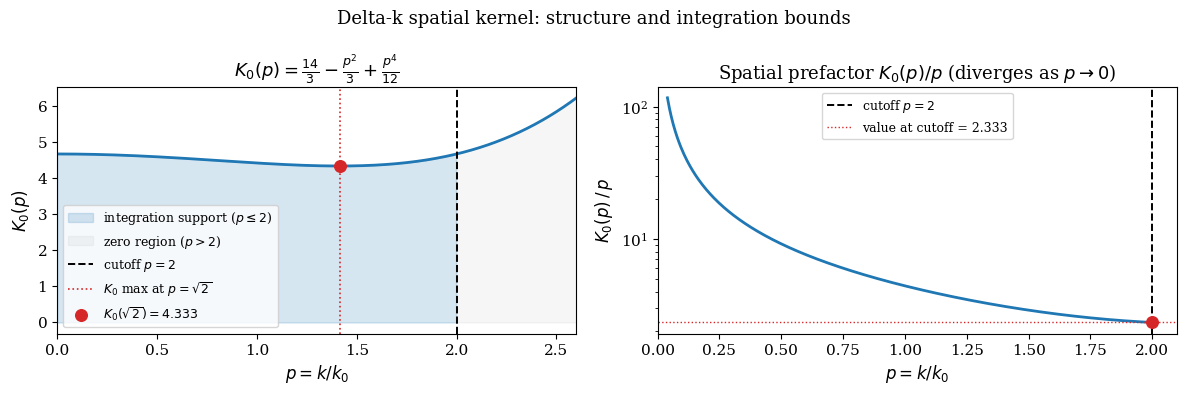

K0(p=2)   = 4.6667
K0(p)/p at p=2 = 2.3333  (minimum on valid range)


In [3]:
ps_dense = np.linspace(1e-3, 2.6, 600)
K0_vals  = K0_p(ps_dense)
ps_valid = ps_dense[ps_dense <= 2.0]

p_K0_max = np.sqrt(2.0)   # analytical maximum of K0(p)
K0_max   = K0_p(p_K0_max)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: K0(p) ──
ax = axes[0]
ax.fill_between(ps_dense[ps_dense <= 2], K0_vals[ps_dense <= 2],
                alpha=0.18, color='C0', label='integration support ($p \\leq 2$)')
ax.fill_between(ps_dense[ps_dense > 2],  K0_vals[ps_dense > 2],
                alpha=0.07, color='gray', label='zero region ($p > 2$)')
ax.plot(ps_dense, K0_vals, 'C0', lw=2)
ax.axvline(2.0, color='k',  lw=1.4, ls='--', label='cutoff $p=2$')
ax.axvline(p_K0_max, color='C3', lw=1.2, ls=':', label=f'$K_0$ max at $p=\\sqrt{{2}}$')
ax.scatter([p_K0_max], [K0_max], color='C3', zorder=5, s=70, label=f'$K_0(\\sqrt{{2}})={K0_max:.3f}$')
ax.set_xlabel('$p = k/k_0$'); ax.set_ylabel('$K_0(p)$')
ax.set_title('$K_0(p) = \\frac{14}{3} - \\frac{p^2}{3} + \\frac{p^4}{12}$')
ax.legend(fontsize=9); ax.set_xlim(0, 2.6)

# ── Right: K0(p)/p ──
ax = axes[1]
ps_v = np.linspace(0.04, 2.0, 500)
ax.plot(ps_v, K0_p(ps_v)/ps_v, 'C0', lw=2)
ax.axvline(2.0, color='k', lw=1.4, ls='--', label='cutoff $p=2$')
ax.axhline(K0_p(2.0)/2.0, color='C3', lw=1, ls=':', label=f'value at cutoff = {K0_p(2.0)/2:.3f}')
ax.scatter([2.0], [K0_p(2.0)/2.0], color='C3', zorder=5, s=70)
ax.set_yscale('log'); ax.set_xlabel('$p = k/k_0$'); ax.set_ylabel('$K_0(p)\\,/\\,p$')
ax.set_title('Spatial prefactor $K_0(p)/p$ (diverges as $p\\to 0$)')
ax.legend(fontsize=9); ax.set_xlim(0, 2.1)

fig.suptitle('Delta-k spatial kernel: structure and integration bounds', fontsize=13)
fig.tight_layout()
plt.savefig(os.path.join(out_dir, 'dk_kernel_K0.pdf'))
plt.show()

bounds_dict['delta_k_kraichnan']['K0_at_cutoff'] = float(K0_p(2.0))
bounds_dict['delta_k_decay']['K0_at_cutoff']     = float(K0_p(2.0))
print(f'K0(p=2)   = {K0_p(2.0):.4f}')
print(f'K0(p)/p at p=2 = {K0_p(2.0)/2:.4f}  (minimum on valid range)')

## 2 · Delta-k Kraichnan: closed-form result

$$\mathfrak{H}^{(\delta k)}_{\rm Kraichnan}(p,\Omega)
= \frac{K_0(p)}{p}\,\Theta(2-p)\,e^{-\Omega^2/(2\pi)}$$

No numerical integration required.  
- **p-peak**: $K_0(p)/p$ is monotonically decreasing on $(0,2]$ → peak at the smallest accessible $p$  
- **$\Omega$-peak**: Gaussian, maximum at $\Omega=0$

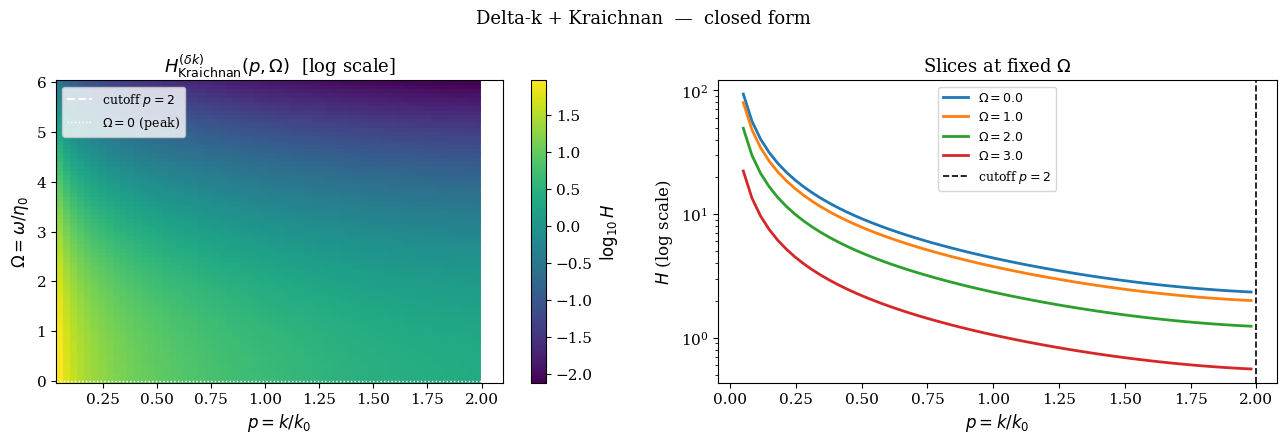

In [4]:
ps_dk     = np.linspace(0.05, 1.98, 60)
Omegas_dk = np.linspace(0.0, 6.0, 70)

PP, OO = np.meshgrid(ps_dk, Omegas_dk)
H_dkK  = H_delta_k_kraichnan(PP, OO)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── 2D colormap ──
ax = axes[0]
pcm = ax.pcolormesh(PP, OO, np.log10(np.maximum(H_dkK, 1e-10)),
                    cmap='viridis', shading='auto')
cb = fig.colorbar(pcm, ax=ax, label='$\\log_{10} H$')
ax.axvline(2.0, color='w', lw=1.5, ls='--', label='cutoff $p=2$')
ax.axhline(0.0, color='w', lw=1.0, ls=':', label='$\\Omega=0$ (peak)')
ax.set_xlabel('$p = k/k_0$'); ax.set_ylabel('$\\Omega = \\omega/\\eta_0$')
ax.set_title('$H^{(\\delta k)}_{\\rm Kraichnan}(p,\\Omega)$  [log scale]')
ax.legend(fontsize=9)

# ── 1D slices ──
ax = axes[1]
colors_Om = ['C0','C1','C2','C3']
for Omega_cut, col in zip([0.0, 1.0, 2.0, 3.0], colors_Om):
    h_slice = H_delta_k_kraichnan(ps_dk, Omega_cut)
    ax.semilogy(ps_dk, h_slice, color=col, label=f'$\\Omega={Omega_cut}$')
ax.axvline(2.0, color='k', lw=1.2, ls='--', label='cutoff $p=2$')
ax.set_xlabel('$p = k/k_0$'); ax.set_ylabel('$H$ (log scale)')
ax.set_title('Slices at fixed $\\Omega$')
ax.legend(fontsize=9)

fig.suptitle('Delta-k + Kraichnan  —  closed form', fontsize=13)
fig.tight_layout()
plt.savefig(os.path.join(out_dir, 'dk_kraichnan_2d_and_slices.pdf'))
plt.show()

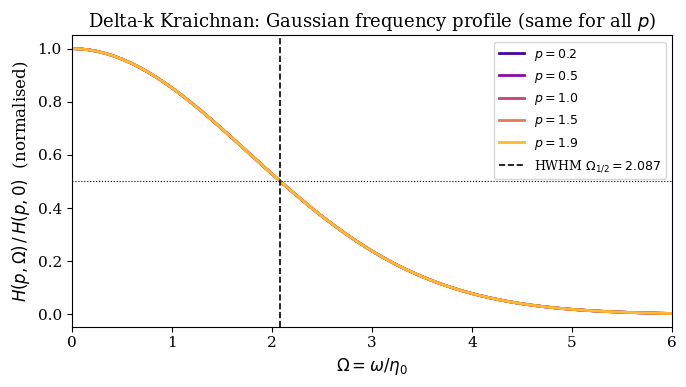

Delta-k Kraichnan peak info:
  p_peak: 0.05
  Omega_peak: 0.0
  H_at_peak: 93.31667708333332
  Omega_half_width: 2.0869049285023036
  note: K0(p)/p monotonically decreasing on (0,2]; peak at smallest p; Gaussian in Omega


In [5]:
# ── Frequency slices at fixed p; mark Gaussian half-width ──
fig, ax = plt.subplots(figsize=(7, 4))

half_width_Omega = np.sqrt(2.0 * np.pi * np.log(2.0))  # e^{-Omega^2/(2pi)} = 1/2
p_fixed_list = [0.2, 0.5, 1.0, 1.5, 1.9]
colors_p     = plt.cm.plasma(np.linspace(0.1, 0.85, len(p_fixed_list)))

for p_fixed, col in zip(p_fixed_list, colors_p):
    h_om = H_delta_k_kraichnan(p_fixed, Omegas_dk)
    ax.plot(Omegas_dk, h_om / h_om[0], color=col, label=f'$p={p_fixed}$')

ax.axvline(half_width_Omega, color='k', lw=1.2, ls='--',
           label=f'HWHM $\\Omega_{{1/2}}={half_width_Omega:.3f}$')
ax.axhline(0.5, color='k', lw=0.8, ls=':')
ax.set_xlabel('$\\Omega = \\omega/\\eta_0$')
ax.set_ylabel('$H(p,\\Omega) \\,/\\, H(p,0)$  (normalised)')
ax.set_title('Delta-k Kraichnan: Gaussian frequency profile (same for all $p$)')
ax.legend(fontsize=9); ax.set_xlim(0, 6)
fig.tight_layout()
plt.savefig(os.path.join(out_dir, 'dk_kraichnan_omega_slices.pdf'))
plt.show()

# ── Find effective peak (smallest p in grid × Omega=0) ──
p_peak_dkK = ps_dk[0]   # K0(p)/p is monotone; 'peak' is at smallest p
H_peak_dkK = float(H_delta_k_kraichnan(p_peak_dkK, 0.0))
peaks_dict['delta_k_kraichnan'] = {
    'p_peak'       : p_peak_dkK,
    'Omega_peak'   : 0.0,
    'H_at_peak'    : H_peak_dkK,
    'Omega_half_width': float(half_width_Omega),
    'note'         : 'K0(p)/p monotonically decreasing on (0,2]; peak at smallest p; Gaussian in Omega',
}
print('Delta-k Kraichnan peak info:')
for k, v in peaks_dict['delta_k_kraichnan'].items():
    print(f'  {k}: {v}')

## 3 · Delta-k Decay: one-dimensional temporal convolution

$$\mathfrak{H}^{(\delta k)}_{\rm decay}(p,q)
= \frac{K_0(p)}{p}\,\Theta(2-p)\;\underbrace{\int_{-\infty}^{\infty} dq_1\,g(q_1)\,g(q-q_1)}_{C(q)},
\qquad g(q)=e^{iq}(-iq)^{-5/3}\Gamma\!\left(\tfrac{1}{3},-iq\right).$$

The spatial delta functions completely fix $k_1=u=k_0$ leaving only the 1-D convolution $C(q)$.


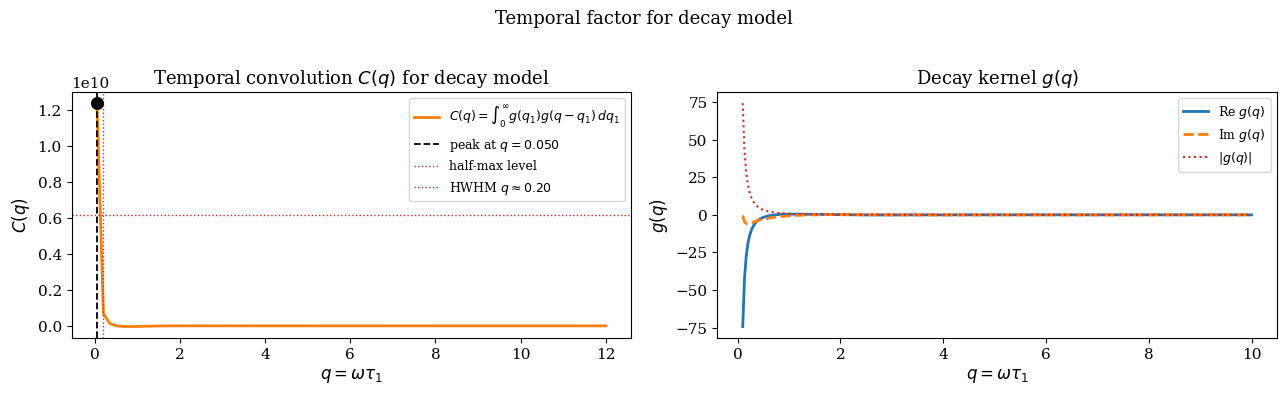

C(q) peak at q = 0.050,  C_peak = 1.2362e+10
HWHM approx at q = 0.201


In [6]:
# ── Compute temporal convolution C(q) = H_delta_k_decay(p=1, q) / K0(1)/1 ──
qs_conv  = np.linspace(0.05, 12.0, 80)
C_vals   = np.array([H_delta_k_decay(1.0, q, n_points=200) / (K0_p(1.0) / 1.0)
                     for q in qs_conv])

# Peak of C(q)
i_conv_peak   = np.argmax(C_vals)
q_conv_peak   = qs_conv[i_conv_peak]
C_peak        = C_vals[i_conv_peak]
q_conv_halfmax = qs_conv[np.argmin(np.abs(C_vals - 0.5 * C_peak))]  # first crossing

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: C(q) ──
ax = axes[0]
ax.plot(qs_conv, C_vals, 'C1', lw=2, label='$C(q) = \\int_0^\\infty g(q_1)g(q-q_1)\\,dq_1$')
ax.axvline(q_conv_peak,    color='k', lw=1.3, ls='--', label=f'peak at $q={q_conv_peak:.3f}$')
ax.axhline(0.5 * C_peak,   color='C3', lw=1.0, ls=':', label='half-max level')
ax.axvline(q_conv_halfmax, color='C3', lw=1.0, ls=':', label=f'HWHM $q\\approx{q_conv_halfmax:.2f}$')
ax.scatter([q_conv_peak], [C_peak], color='k', zorder=5, s=70)
ax.set_xlabel('$q = \\omega\\tau_1$'); ax.set_ylabel('$C(q)$')
ax.set_title('Temporal convolution $C(q)$ for decay model')
ax.legend(fontsize=9)

# ── Right: g(q) components ──
qs_g = np.linspace(0.1, 10, 300)
gz   = g_decaying(qs_g)
ax = axes[1]
ax.plot(qs_g, gz.real, 'C0', lw=2, label='Re $g(q)$')
ax.plot(qs_g, gz.imag, 'C1', lw=2, ls='--', label='Im $g(q)$')
ax.plot(qs_g, np.abs(gz), 'C3', lw=1.5, ls=':', label='$|g(q)|$')
ax.set_xlabel('$q = \\omega\\tau_1$'); ax.set_ylabel('$g(q)$')
ax.set_title('Decay kernel $g(q)$')
ax.legend(fontsize=9)

fig.suptitle('Temporal factor for decay model', fontsize=13)
fig.tight_layout()
plt.savefig(os.path.join(out_dir, 'dk_decay_temporal.pdf'))
plt.show()

print(f'C(q) peak at q = {q_conv_peak:.3f},  C_peak = {C_peak:.4e}')
print(f'HWHM approx at q = {q_conv_halfmax:.3f}')

Loaded from cache: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/cache_delta_k_decay.npz


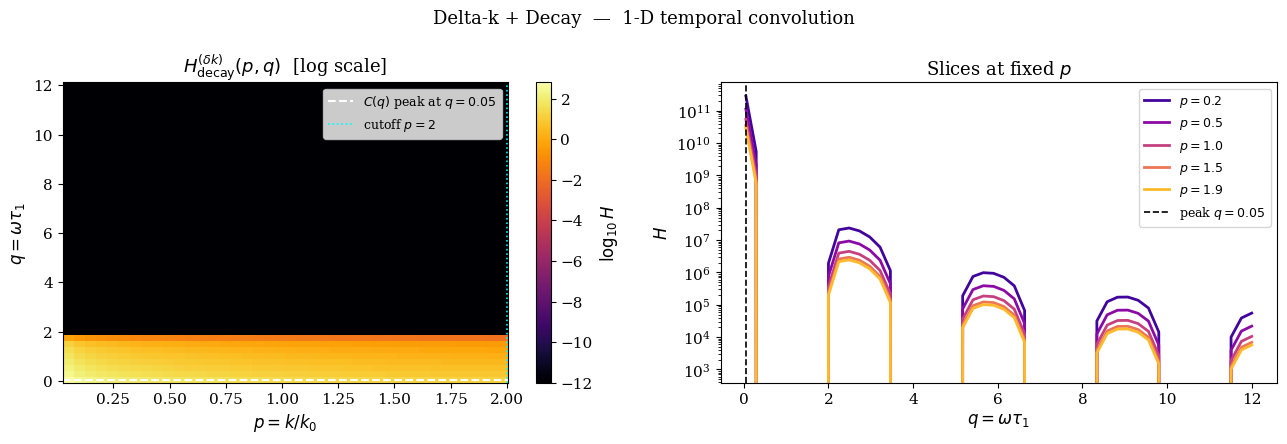

Delta-k Decay peak: {'p_peak': 0.05, 'q_peak': 0.05, 'H_at_peak': 628.5305204733938, 'C_q_peak': 0.05, 'C_HWHM': 0.20126582278481014, 'note': 'Spatial factor K0(p)/p same as Kraichnan; temporal factor C(q) from g-convolution'}


In [7]:
# ── 2-D grid for delta-k Decay ──
cache_dkD = os.path.join(out_dir, 'cache_delta_k_decay.npz')
ps_dk2 = np.linspace(0.05, 1.98, 40)
qs_dk2 = np.linspace(0.05, 12.0, 50)

if os.path.exists(cache_dkD):
    d = np.load(cache_dkD)
    H_dkD = d['H_dkD']; ps_dk2 = d['ps_dk2']; qs_dk2 = d['qs_dk2']
    print(f'Loaded from cache: {cache_dkD}')
else:
    print('Computing H_delta_k_decay grid ...')
    t0 = time.time()
    H_dkD = H_delta_k_decay_grid(ps_dk2, qs_dk2, n_points=200)
    print(f'Done in {time.time()-t0:.1f}s')
    np.savez(cache_dkD, H_dkD=H_dkD, ps_dk2=ps_dk2, qs_dk2=qs_dk2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── 2D colormap ──
ax = axes[0]
pcm = ax.pcolormesh(ps_dk2, qs_dk2, np.log10(np.maximum(H_dkD, 1e-12)),
                    cmap='inferno', shading='auto')
fig.colorbar(pcm, ax=ax, label='$\\log_{10} H$')
# Mark peak of C(q)
ax.axhline(q_conv_peak, color='w', lw=1.5, ls='--', label=f'$C(q)$ peak at $q={q_conv_peak:.2f}$')
ax.axvline(2.0, color='cyan', lw=1.2, ls=':', label='cutoff $p=2$')
ax.set_xlabel('$p = k/k_0$'); ax.set_ylabel('$q = \\omega\\tau_1$')
ax.set_title('$H^{(\\delta k)}_{\\rm decay}(p,q)$  [log scale]')
ax.legend(fontsize=9)

# ── 1D slices in q at fixed p ──
ax = axes[1]
for p_fixed, col in zip([0.2, 0.5, 1.0, 1.5, 1.9],
                         plt.cm.plasma(np.linspace(0.1, 0.85, 5))):
    h_col = np.array([H_delta_k_decay(p_fixed, q, n_points=200) for q in qs_dk2])
    ax.semilogy(qs_dk2, h_col, color=col, label=f'$p={p_fixed}$')
ax.axvline(q_conv_peak, color='k', lw=1.2, ls='--', label=f'peak $q={q_conv_peak:.2f}$')
ax.set_xlabel('$q = \\omega\\tau_1$'); ax.set_ylabel('$H$')
ax.set_title('Slices at fixed $p$')
ax.legend(fontsize=9)

fig.suptitle('Delta-k + Decay  —  1-D temporal convolution', fontsize=13)
fig.tight_layout()
plt.savefig(os.path.join(out_dir, 'dk_decay_2d_and_slices.pdf'))
plt.show()

# ── Find peak of full 2D grid ──
idx_peak = np.unravel_index(np.argmax(H_dkD), H_dkD.shape)
peaks_dict['delta_k_decay'] = {
    'p_peak'        : float(ps_dk2[idx_peak[1]]),
    'q_peak'        : float(qs_dk2[idx_peak[0]]),
    'H_at_peak'     : float(H_dkD[idx_peak]),
    'C_q_peak'      : float(q_conv_peak),
    'C_HWHM'        : float(q_conv_halfmax),
    'note'          : 'Spatial factor K0(p)/p same as Kraichnan; temporal factor C(q) from g-convolution',
}
print('Delta-k Decay peak:', peaks_dict['delta_k_decay'])

## 4 · White-noise spatial model: integration domain in the $(z, y)$ plane

For $R^{3/4}=k_d/k_0=$ `Rd34`, the integration domain for the **2-D spatial integral** $S(p,R)$ is
$$z \in [1,\, R^{3/4}], \qquad y \in [\max(|p-z|,1),\; \min(p+z, R^{3/4})].$$
This region shrinks toward zero measure as $p\to 0$ or $p > 2R^{3/4}$.

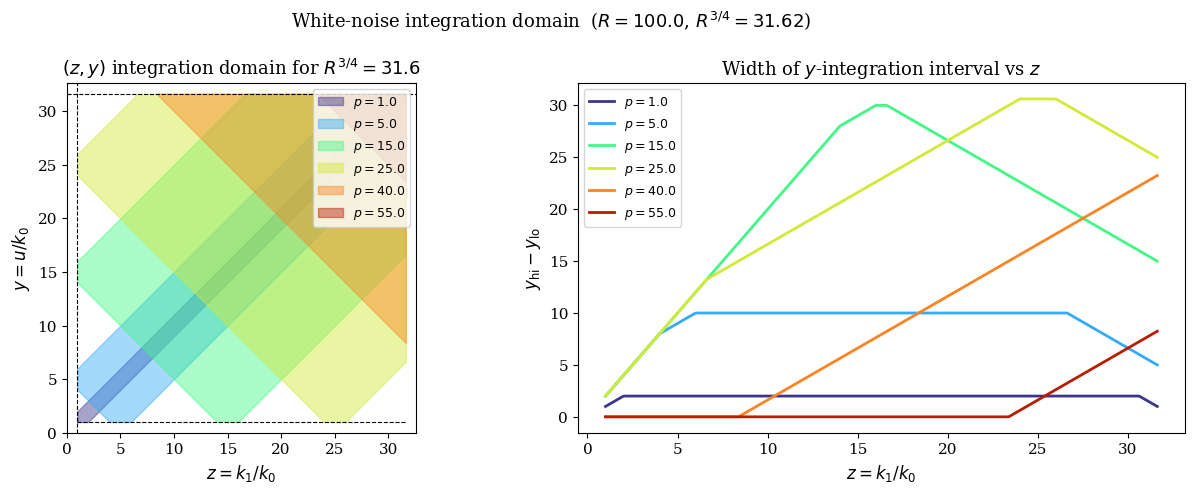

Domain vanishes for p > 2*Rd34 = 63.25


In [8]:
z_plot = np.linspace(1.0, Rd34, 500)
p_domain_list = [1.0, 5.0, 15.0, 25.0, 40.0, 55.0]
colors_dom = plt.cm.turbo(np.linspace(0.05, 0.92, len(p_domain_list)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: 2-D domain in (z, y) plane ──
ax = axes[0]
ax.set_aspect('equal')
for p_val, col in zip(p_domain_list, colors_dom):
    y_lo = np.maximum(np.abs(p_val - z_plot), 1.0)
    y_hi = np.minimum(p_val + z_plot, Rd34)
    valid = y_hi > y_lo
    if valid.any():
        ax.fill_between(z_plot[valid], y_lo[valid], y_hi[valid],
                        alpha=0.45, color=col, label=f'$p={p_val}$')
ax.set_xlim(0, Rd34 + 1); ax.set_ylim(0, Rd34 + 1)
ax.plot([1, Rd34], [1, 1], 'k--', lw=0.8)   # y = 1 floor
ax.axhline(Rd34, color='k', lw=0.8, ls='--')  # y = Rd34 ceiling
ax.axvline(1.0,  color='k', lw=0.8, ls='--')  # z = 1 floor
ax.set_xlabel('$z = k_1/k_0$'); ax.set_ylabel('$y = u/k_0$')
ax.set_title(f'$(z,y)$ integration domain for $R^{{3/4}}={Rd34:.1f}$')
ax.legend(fontsize=9, loc='upper right')

# ── Right: domain width in y vs z for each p ──
ax = axes[1]
for p_val, col in zip(p_domain_list, colors_dom):
    y_lo = np.maximum(np.abs(p_val - z_plot), 1.0)
    y_hi = np.minimum(p_val + z_plot, Rd34)
    width = np.maximum(y_hi - y_lo, 0.0)
    ax.plot(z_plot, width, color=col, lw=2, label=f'$p={p_val}$')
ax.set_xlabel('$z = k_1/k_0$'); ax.set_ylabel('$y_{\\rm hi} - y_{\\rm lo}$')
ax.set_title('Width of $y$-integration interval vs $z$')
ax.legend(fontsize=9)

fig.suptitle(f'White-noise integration domain  ($R={R_WHITE}$, $R^{{3/4}}={Rd34:.2f}$)', fontsize=13)
fig.tight_layout()
plt.savefig(os.path.join(out_dir, 'white_integration_domain.pdf'))
plt.show()

# ── Record the p values where the domain vanishes ──
bounds_dict['white_kraichnan']['p_zero_above'] = float(2.0 * Rd34)
bounds_dict['white_decay']['p_zero_above']     = float(2.0 * Rd34)
print(f'Domain vanishes for p > 2*Rd34 = {2.0*Rd34:.2f}')

## 5 · White-noise Kraichnan: 2-D spatial integral × Gaussian

$$\mathfrak{H}^{(\delta r)}_{\rm Kraichnan}(p,\Omega)
= e^{-\Omega^2/(2\pi)}\cdot S(p,R),
\qquad S(p,R)=\int_1^{R^{3/4}}\frac{z}{p}\,dz\int_{y_{\rm lo}}^{y_{\rm hi}}y\,dy\,\widetilde{\mathcal{K}}(p,z,y).$$

The spatial factor $S(p,R)$ is computed once per $(p,R)$ pair and reused for all $\Omega$.

Loaded S(p) from cache: /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/cache_white_S.npz


/tmp/ipykernel_158602/2249904769.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val   = np.trapz(y_arr * K_arr, y_arr) * z / p_show


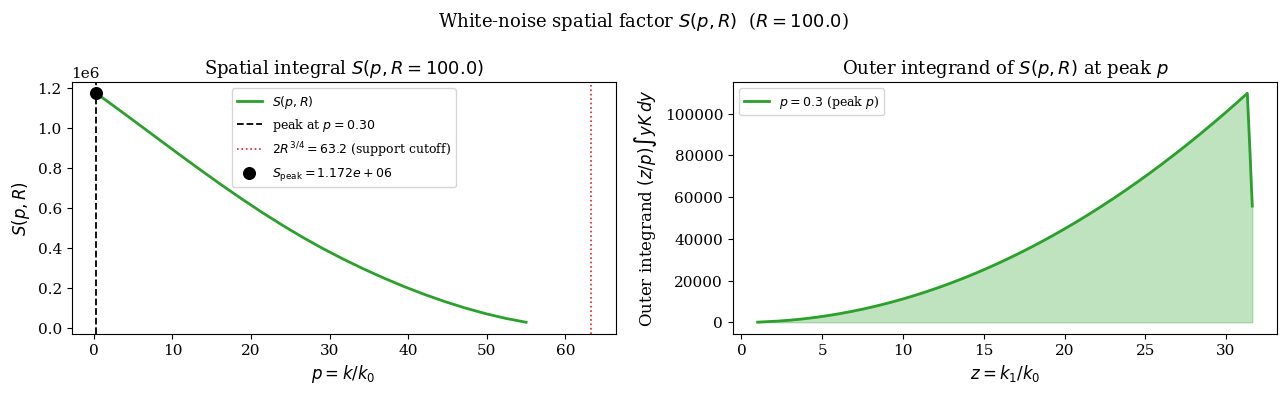

S(p) peak: p_peak = 0.300,  S_peak = 1.1722e+06


In [9]:
# ── S(p) = H_white_kraichnan(p, 0, R) at Omega=0 ──
cache_S = os.path.join(out_dir, 'cache_white_S.npz')
ps_white = np.concatenate([np.linspace(0.3, 5, 15), np.linspace(6, 55, 20)])
ps_white = np.unique(ps_white)

if os.path.exists(cache_S):
    d = np.load(cache_S)
    S_vals = d['S_vals']; ps_white = d['ps_white']
    print(f'Loaded S(p) from cache: {cache_S}')
else:
    print(f'Computing S(p) for {len(ps_white)} p values  (R={R_WHITE}) ...')
    t0 = time.time()
    S_vals = np.array([H_white_kraichnan(p, 0.0, R=R_WHITE) for p in ps_white])
    print(f'Done in {time.time()-t0:.1f}s')
    np.savez(cache_S, S_vals=S_vals, ps_white=ps_white, R=R_WHITE)

# Peak of S(p)
i_S_peak = np.argmax(S_vals)
p_S_peak = ps_white[i_S_peak]
S_peak   = S_vals[i_S_peak]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: S(p) ──
ax = axes[0]
ax.plot(ps_white, S_vals, 'C2', lw=2, label='$S(p, R)$')
ax.axvline(p_S_peak, color='k', lw=1.3, ls='--', label=f'peak at $p={p_S_peak:.2f}$')
ax.axvline(2.0 * Rd34, color='C3', lw=1.2, ls=':', label=f'$2R^{{3/4}}={2*Rd34:.1f}$ (support cutoff)')
ax.scatter([p_S_peak], [S_peak], color='k', zorder=5, s=70, label=f'$S_{{\\rm peak}}={S_peak:.3e}$')
ax.set_xlabel('$p = k/k_0$'); ax.set_ylabel('$S(p, R)$')
ax.set_title(f'Spatial integral $S(p, R={R_WHITE})$')
ax.legend(fontsize=9)

# ── Right: integrand of S at p=p_S_peak along z ──
# (z/p) * int_y y*K dy  — the outer integrand
z_fine = np.linspace(1.0, Rd34, 200)
p_show = p_S_peak
outer_integrand = []
for z in z_fine:
    y_lo = max(abs(p_show - z), 1.0)
    y_hi = min(p_show + z, Rd34)
    if y_hi > y_lo:
        y_arr = np.linspace(y_lo, y_hi, 80)
        K_arr = np.array([kernel_bracket_zy(p_show, z, y) for y in y_arr])
        val   = np.trapz(y_arr * K_arr, y_arr) * z / p_show
    else:
        val = 0.0
    outer_integrand.append(val)
outer_integrand = np.array(outer_integrand)

ax = axes[1]
ax.fill_between(z_fine, outer_integrand, alpha=0.3, color='C2')
ax.plot(z_fine, outer_integrand, 'C2', lw=2, label=f'$p={p_show:.1f}$ (peak $p$)')
ax.set_xlabel('$z = k_1/k_0$'); ax.set_ylabel('Outer integrand $(z/p)\\int y K\\,dy$')
ax.set_title('Outer integrand of $S(p,R)$ at peak $p$')
ax.legend(fontsize=9)

fig.suptitle(f'White-noise spatial factor $S(p,R)$  ($R={R_WHITE}$)', fontsize=13)
fig.tight_layout()
plt.savefig(os.path.join(out_dir, 'white_spatial_S.pdf'))
plt.show()

print(f'S(p) peak: p_peak = {p_S_peak:.3f},  S_peak = {S_peak:.4e}')

Loaded white-Kraichnan grid from cache.


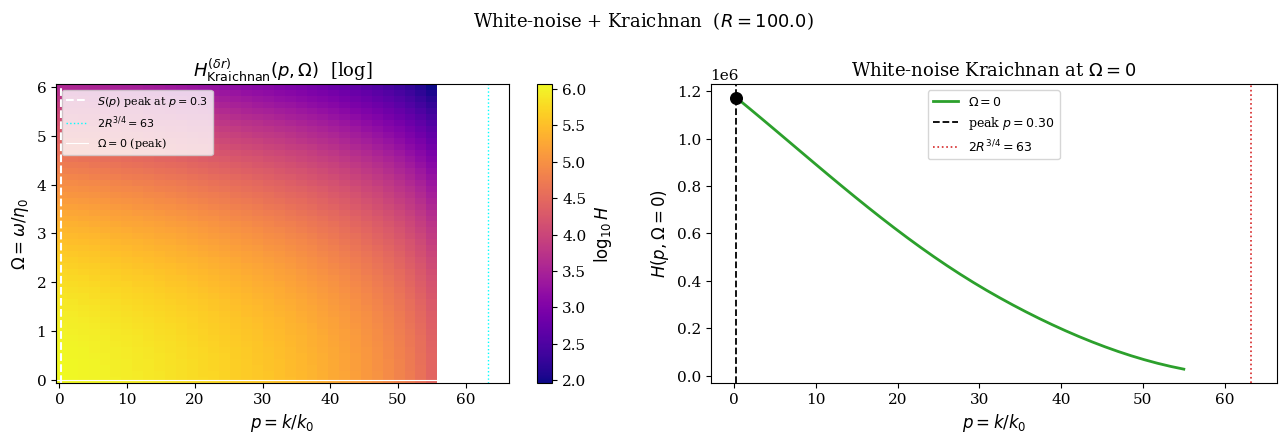

White-noise Kraichnan peak: {'p_peak': 0.3, 'Omega_peak': 0.0, 'H_at_peak': 1172150.459923595, 'p_support_cutoff': 63.245553203367585, 'Omega_half_width': 2.0869049285023036, 'note': 'S(p) peaks at intermediate p; Gaussian factor same shape as delta-k Kraichnan'}


In [10]:
# ── 2-D grid: white-noise Kraichnan ──
cache_wK = os.path.join(out_dir, 'cache_white_kraichnan_grid.npz')
ps_wK    = np.linspace(0.3, 55, 35)
Oms_wK   = np.linspace(0.0, 6.0, 50)

if os.path.exists(cache_wK):
    d = np.load(cache_wK)
    H_wK = d['H_wK']; ps_wK = d['ps_wK']; Oms_wK = d['Oms_wK']
    print(f'Loaded white-Kraichnan grid from cache.')
else:
    print('Computing H_white_kraichnan_grid ...')
    t0 = time.time()
    H_wK = H_white_kraichnan_grid(ps_wK, Oms_wK, R=R_WHITE)
    print(f'Done in {time.time()-t0:.1f}s')
    np.savez(cache_wK, H_wK=H_wK, ps_wK=ps_wK, Oms_wK=Oms_wK)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── 2D colormap ──
PP_w, OO_w = np.meshgrid(ps_wK, Oms_wK)
ax = axes[0]
pcm = ax.pcolormesh(PP_w, OO_w, np.log10(np.maximum(H_wK, 1e-20)),
                    cmap='plasma', shading='auto')
fig.colorbar(pcm, ax=ax, label='$\\log_{10} H$')
ax.axvline(p_S_peak, color='w', lw=1.5, ls='--', label=f'$S(p)$ peak at $p={p_S_peak:.1f}$')
ax.axvline(2*Rd34,   color='cyan', lw=1.0, ls=':', label=f'$2R^{{3/4}}={2*Rd34:.0f}$')
ax.axhline(0.0,      color='w', lw=0.8, ls='-', label='$\\Omega=0$ (peak)')
ax.set_xlabel('$p = k/k_0$'); ax.set_ylabel('$\\Omega = \\omega/\\eta_0$')
ax.set_title('$H^{(\\delta r)}_{\\rm Kraichnan}(p,\\Omega)$  [log]')
ax.legend(fontsize=8)

# ── p-slices at Omega=0 ──
ax = axes[1]
H_wK_Om0 = np.array([H_white_kraichnan(p, 0.0, R=R_WHITE) for p in ps_wK])
ax.plot(ps_wK, H_wK_Om0, 'C2', lw=2, label='$\\Omega=0$')
ax.axvline(p_S_peak, color='k', lw=1.3, ls='--', label=f'peak $p={p_S_peak:.2f}$')
ax.axvline(2*Rd34,   color='C3', lw=1.2, ls=':', label=f'$2R^{{3/4}}={2*Rd34:.0f}$')
ax.scatter([p_S_peak], [S_peak], color='k', zorder=5, s=70)
ax.set_xlabel('$p = k/k_0$'); ax.set_ylabel('$H(p, \\Omega=0)$')
ax.set_title('White-noise Kraichnan at $\\Omega=0$')
ax.legend(fontsize=9)

fig.suptitle(f'White-noise + Kraichnan  ($R={R_WHITE}$)', fontsize=13)
fig.tight_layout()
plt.savefig(os.path.join(out_dir, 'white_kraichnan_2d_and_slices.pdf'))
plt.show()

half_width_Om = np.sqrt(2.0 * np.pi * np.log(2.0))  # same Gaussian as delta-k Kraichnan
peaks_dict['white_kraichnan'] = {
    'p_peak'           : float(p_S_peak),
    'Omega_peak'       : 0.0,
    'H_at_peak'        : float(S_peak),
    'p_support_cutoff' : float(2.0 * Rd34),
    'Omega_half_width' : float(half_width_Om),
    'note'             : 'S(p) peaks at intermediate p; Gaussian factor same shape as delta-k Kraichnan',
}
print('White-noise Kraichnan peak:', peaks_dict['white_kraichnan'])

## 6 · White-noise Decay: separable 3-D integral

$$\mathfrak{H}^{(\delta r)}_{\rm decay}(p,q)
= \underbrace{S(p,R)}_{\text{2-D spatial}} \times
  \underbrace{C(q)}_{\text{1-D temporal}},$$
where $S$ and $C$ are the same factors computed above — they are **fully independent**.

Loaded C(q) from cache.


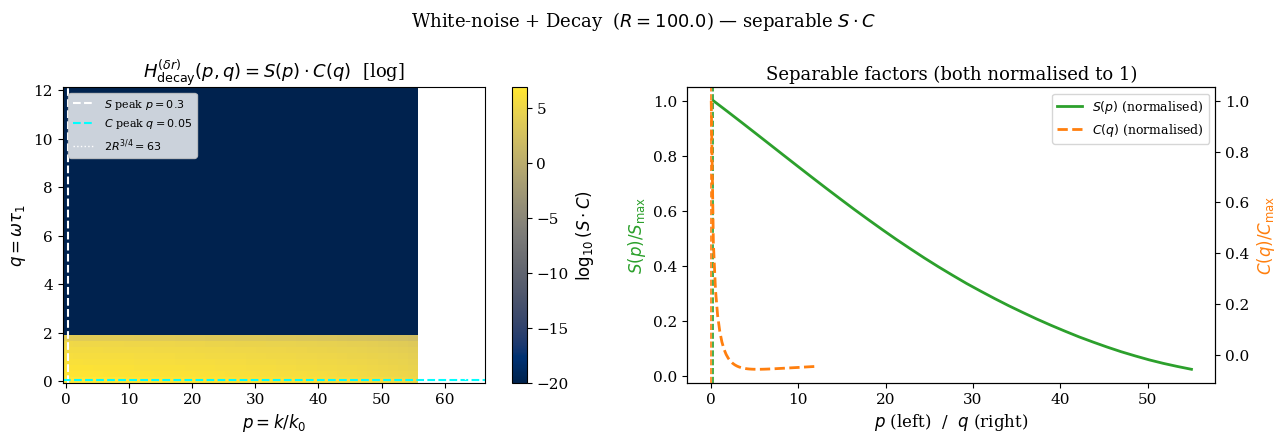

White-noise Decay peak: {'p_peak': 0.3, 'q_peak': 0.05, 'H_at_peak': 7894969.706122209, 'p_support_cutoff': 63.245553203367585, 'C_q_peak': 0.05, 'note': 'H = S(p)*C(q); peaks are independent in p and q'}


In [11]:
# ── Build 2-D grid as outer product S(p) * C(q) ──
# C(q) was already computed for the delta-k decay section.
# Interpolate S onto ps_wK using the cached values.
S_interp = np.interp(ps_wK, ps_white, S_vals)

# Build C on the qs_dk2 frequency grid
cache_C = os.path.join(out_dir, 'cache_C_conv.npz')
qs_wD   = np.linspace(0.05, 12.0, 50)
if os.path.exists(cache_C):
    d2 = np.load(cache_C)
    C_wD = d2['C_wD']; qs_wD = d2['qs_wD']
    print('Loaded C(q) from cache.')
else:
    print('Computing C(q) for white-decay grid ...')
    t0 = time.time()
    C_wD = np.array([H_delta_k_decay(1.0, q, n_points=200) / (K0_p(1.0) / 1.0)
                     for q in qs_wD])
    print(f'Done in {time.time()-t0:.1f}s')
    np.savez(cache_C, C_wD=C_wD, qs_wD=qs_wD)

# Outer product
H_wD = np.outer(C_wD, S_interp)   # shape (n_q, n_p)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── 2D colormap ──
PP_wd, QQ_wd = np.meshgrid(ps_wK, qs_wD)
ax = axes[0]
pcm = ax.pcolormesh(PP_wd, QQ_wd, np.log10(np.maximum(H_wD, 1e-20)),
                    cmap='cividis', shading='auto')
fig.colorbar(pcm, ax=ax, label='$\\log_{10}(S \\cdot C)$')
ax.axvline(p_S_peak,    color='w',    lw=1.5, ls='--', label=f'$S$ peak $p={p_S_peak:.1f}$')
ax.axhline(q_conv_peak, color='cyan', lw=1.5, ls='--', label=f'$C$ peak $q={q_conv_peak:.2f}$')
ax.axvline(2*Rd34, color='w', lw=1.0, ls=':', label=f'$2R^{{3/4}}={2*Rd34:.0f}$')
ax.set_xlabel('$p = k/k_0$'); ax.set_ylabel('$q = \\omega\\tau_1$')
ax.set_title('$H^{(\\delta r)}_{\\rm decay}(p,q) = S(p)\\cdot C(q)$  [log]')
ax.legend(fontsize=8)

# ── Factored view: S(p) and C(q) on shared axes ──
ax = axes[1]
ax_twin = ax.twinx()
l1, = ax.plot(ps_wK, S_interp / S_interp.max(), 'C2', lw=2, label='$S(p)$ (normalised)')
ax.axvline(p_S_peak, color='C2', lw=1.2, ls='--')
l2, = ax_twin.plot(qs_wD, C_wD / C_wD.max(), 'C1', lw=2, ls='--', label='$C(q)$ (normalised)')
ax_twin.axvline(q_conv_peak, color='C1', lw=1.2, ls='--')
ax.set_xlabel('$p$ (left)  /  $q$ (right)')
ax.set_ylabel('$S(p)/S_{\\rm max}$', color='C2')
ax_twin.set_ylabel('$C(q)/C_{\\rm max}$', color='C1')
ax.set_title('Separable factors (both normalised to 1)')
lines = [l1, l2]
ax.legend(lines, [l.get_label() for l in lines], fontsize=9)

fig.suptitle(f'White-noise + Decay  ($R={R_WHITE}$) — separable $S\\cdot C$', fontsize=13)
fig.tight_layout()
plt.savefig(os.path.join(out_dir, 'white_decay_2d_and_factors.pdf'))
plt.show()

i_wD = np.unravel_index(np.argmax(H_wD), H_wD.shape)
peaks_dict['white_decay'] = {
    'p_peak'           : float(ps_wK[i_wD[1]]),
    'q_peak'           : float(qs_wD[i_wD[0]]),
    'H_at_peak'        : float(H_wD[i_wD]),
    'p_support_cutoff' : float(2.0 * Rd34),
    'C_q_peak'         : float(q_conv_peak),
    'note'             : 'H = S(p)*C(q); peaks are independent in p and q',
}
print('White-noise Decay peak:', peaks_dict['white_decay'])

## 7 · All-four-model comparison

We compare all four models side by side:
- **Left**: frequency slice at fixed $p=1$ (or $p$ nearest to 1 in each grid)
- **Right**: spatial slice at $\Omega=0$ (Kraichnan) or $q=q_{\rm peak}$ (decay)

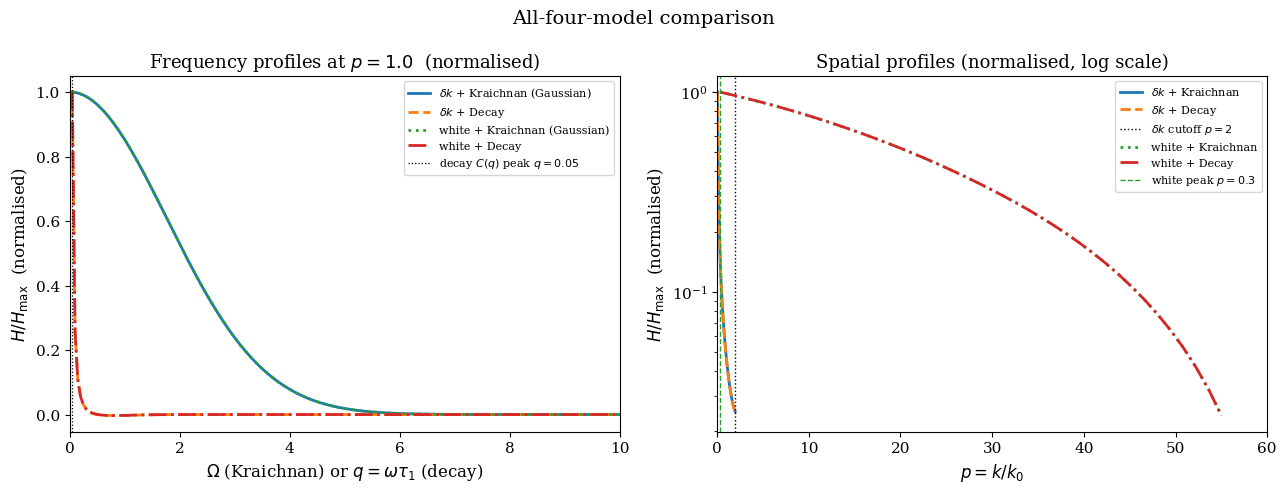

In [12]:
f_common = np.linspace(0.05, 10.0, 200)   # shared frequency axis (Omega or q)
p_fixed  = 1.0

# --- delta-k ---
h_dkK_freq = H_delta_k_kraichnan(p_fixed, f_common)            # vs Omega
h_dkD_freq = np.array([H_delta_k_decay(p_fixed, q, n_points=200) for q in f_common])  # vs q

# --- white (evaluate S(p) once then multiply) ---
S_at_p1  = H_white_kraichnan(p_fixed, 0.0, R=R_WHITE)          # S(p=1)
h_wK_freq = S_at_p1 * np.exp(-f_common**2 / (2.0 * np.pi))    # vs Omega
h_wD_freq = S_at_p1 * np.array(
    [H_delta_k_decay(1.0, q, n_points=200) / (K0_p(1.0) / 1.0) for q in f_common])  # S*C

# Normalize each to its own peak for shape comparison
def norm(arr):
    mx = np.nanmax(arr)
    return arr / mx if mx > 0 else arr

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: frequency profiles (normalised) ──
ax = axes[0]
ax.plot(f_common, norm(h_dkK_freq), 'C0', lw=2,      label='$\\delta k$ + Kraichnan (Gaussian)')
ax.plot(f_common, norm(h_dkD_freq), 'C1', lw=2, ls='--', label='$\\delta k$ + Decay')
ax.plot(f_common, norm(h_wK_freq),  'C2', lw=2, ls=':',  label='white + Kraichnan (Gaussian)')
ax.plot(f_common, norm(h_wD_freq),  'C3', lw=2, ls='-.', label='white + Decay')
ax.axvline(q_conv_peak, color='k', lw=0.9, ls=':', label=f'decay $C(q)$ peak $q={q_conv_peak:.2f}$')
ax.set_xlabel('$\\Omega$ (Kraichnan) or $q=\\omega\\tau_1$ (decay)')
ax.set_ylabel('$H / H_{\\rm max}$  (normalised)')
ax.set_title(f'Frequency profiles at $p={p_fixed}$  (normalised)')
ax.legend(fontsize=8); ax.set_xlim(0, 10)

# ── Right: spatial profiles (normalised) at zero / peak frequency ──
ps_cmp = np.linspace(0.05, 1.98, 60)
h_dkK_p = H_delta_k_kraichnan(ps_cmp, 0.0)
h_dkD_p = np.array([H_delta_k_decay(p, q_conv_peak, n_points=200) for p in ps_cmp])

ps_wK_cmp = np.linspace(0.3, 55, 40)
h_wK_p = np.array([H_white_kraichnan(p, 0.0, R=R_WHITE) for p in ps_wK_cmp])
S_all  = np.array([H_white_kraichnan(p, 0.0, R=R_WHITE) for p in ps_wK_cmp])
C_at_qpeak = float(H_delta_k_decay(1.0, q_conv_peak, n_points=200) / (K0_p(1.0)/1.0))
h_wD_p = S_all * C_at_qpeak

ax = axes[1]
# delta-k models on left x-axis (p up to 2)
ax.semilogy(ps_cmp, norm(h_dkK_p), 'C0', lw=2,      label='$\\delta k$ + Kraichnan')
ax.semilogy(ps_cmp, norm(h_dkD_p), 'C1', lw=2, ls='--', label='$\\delta k$ + Decay')
ax.axvline(2.0, color='k', lw=1.0, ls=':', label='$\\delta k$ cutoff $p=2$')
# white-noise models
ax.semilogy(ps_wK_cmp, norm(h_wK_p), 'C2', lw=2, ls=':',  label='white + Kraichnan')
ax.semilogy(ps_wK_cmp, norm(h_wD_p), 'C3', lw=2, ls='-.', label='white + Decay')
ax.axvline(p_S_peak, color='C2', lw=1.0, ls='--', label=f'white peak $p={p_S_peak:.1f}$')
ax.set_xlabel('$p = k/k_0$'); ax.set_ylabel('$H / H_{\\rm max}$  (normalised)')
ax.set_title('Spatial profiles (normalised, log scale)')
ax.legend(fontsize=8); ax.set_xlim(0, 60)

fig.suptitle('All-four-model comparison', fontsize=14)
fig.tight_layout()
plt.savefig(os.path.join(out_dir, 'all4_comparison.pdf'))
plt.show()

## 8 · 2 × 2 overview: colormaps of all four models

Panel 1 done.
Panel 2 done.
Panels 3 and 4 done.


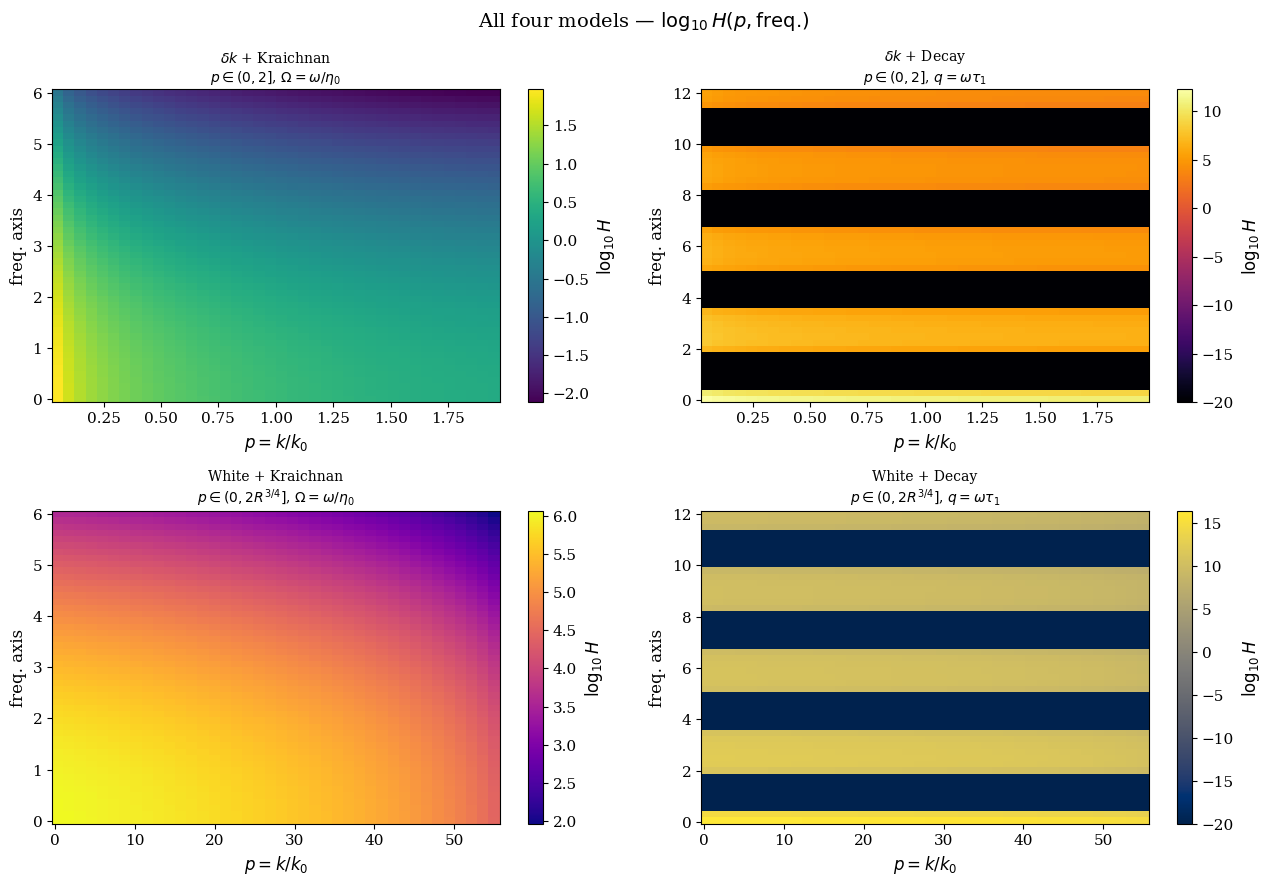

Saved all4_colormaps.pdf


In [13]:
# ── Shared grids (coarse for speed) ──
ps_ov  = np.linspace(0.05, 1.95, 40)   # delta-k p range
ps_ov2 = np.linspace(0.3,  55.0, 40)   # white p range
Oms_ov = np.linspace(0, 6.0, 50)       # Kraichnan frequency axis
qs_ov  = np.linspace(0.05, 12.0, 50)   # Decay frequency axis

PP1, OO1 = np.meshgrid(ps_ov,  Oms_ov)
PP2, OO2 = np.meshgrid(ps_ov,  qs_ov)
PP3, OO3 = np.meshgrid(ps_ov2, Oms_ov)
PP4, OO4 = np.meshgrid(ps_ov2, qs_ov)

H1 = H_delta_k_kraichnan(PP1, OO1)  # fully vectorised, fast
print('Panel 1 done.')

# Load delta-k decay grid from cache
H2 = H_delta_k_decay_grid(ps_ov, qs_ov, n_points=160)
print('Panel 2 done.')

# Build white grids from cached S and C
S_ov  = np.interp(ps_ov2, ps_white, S_vals)
C_ov  = np.array([H_delta_k_decay(1.0, q, n_points=160) / (K0_p(1.0)/1.0) for q in qs_ov])
H3    = np.exp(-OO3**2 / (2.0*np.pi)) * S_ov[np.newaxis, :]  # white Kraichnan
H4    = C_ov[:, np.newaxis] * S_ov[np.newaxis, :]             # white Decay
print('Panels 3 and 4 done.')

titles = [
    '$\\delta k$ + Kraichnan\n$p\\in(0,2]$, $\\Omega=\\omega/\\eta_0$',
    '$\\delta k$ + Decay\n$p\\in(0,2]$, $q=\\omega\\tau_1$',
    'White + Kraichnan\n$p\\in(0, 2R^{3/4}]$, $\\Omega=\\omega/\\eta_0$',
    'White + Decay\n$p\\in(0, 2R^{3/4}]$, $q=\\omega\\tau_1$',
]
grids  = [H1, H2, H3, H4]
PP_all = [PP1, PP2, PP3, PP4]
OO_all = [OO1, OO2, OO3, OO4]
cmaps  = ['viridis', 'inferno', 'plasma', 'cividis']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, H, PP, OO, title, cmap in zip(axes.flat, grids, PP_all, OO_all, titles, cmaps):
    pcm = ax.pcolormesh(PP, OO, np.log10(np.maximum(H, 1e-20)),
                        cmap=cmap, shading='auto')
    fig.colorbar(pcm, ax=ax, label='$\\log_{10} H$')
    ax.set_xlabel('$p = k/k_0$')
    ax.set_ylabel('freq. axis')
    ax.set_title(title, fontsize=10)

fig.suptitle('All four models — $\\log_{10}H(p, \\text{freq.})$', fontsize=14)
fig.tight_layout()
plt.savefig(os.path.join(out_dir, 'all4_colormaps.pdf'))
plt.show()
print('Saved all4_colormaps.pdf')

## 9 · Frequency power-law exponents (log–log)

The only frequency-dependent factors are:

| Model | Freq. factor | Shape |
|---|---|---|
| Kraichnan (any spatial) | $e^{-\Omega^2/(2\pi)}$ | Gaussian — **no** power law |
| Decay (any spatial) | $C(q)=\int_{-\infty}^{\infty} g\,g\,dq_1$ | Numerical — fit slopes in each regime |

We plot $H$ and the GW characteristic-strain proxy $\sqrt{q\,H}$ on **log–log** axes.  
Straight lines = genuine power laws $H \sim q^\alpha$.  
Fitted slopes are extracted with `numpy.polyfit` in three frequency windows.

In [14]:
# ── Dense log-spaced C(q) for slope fitting ─────────────────────────────────
cache_Cdense = os.path.join(out_dir, 'cache_C_dense.npz')
qs_log = np.logspace(-2, 1.5, 120)   # q from 0.01 to ~32

if os.path.exists(cache_Cdense):
    dd = np.load(cache_Cdense)
    C_log = dd['C_log'];  qs_log = dd['qs_log']
    print(f'Loaded dense C(q) from cache.')
else:
    print(f'Computing C(q) on {len(qs_log)}-point log grid ...')
    t0 = time.time()
    C_log = np.array([H_delta_k_decay(1.0, q, n_points=300) / (K0_p(1.0) / 1.0)
                      for q in qs_log])
    print(f'Done in {time.time()-t0:.1f}s')
    np.savez(cache_Cdense, C_log=C_log, qs_log=qs_log)

# ── Helper: fit power-law slope in a q window ────────────────────────────────
def fit_slope(qs, vals, q_lo, q_hi):
    """Return (slope, intercept) from log10–log10 polyfit in window [q_lo, q_hi]."""
    mask = (qs >= q_lo) & (qs <= q_hi) & (vals > 0)
    if mask.sum() < 3:
        return np.nan, np.nan
    return np.polyfit(np.log10(qs[mask]), np.log10(vals[mask]), 1)

def guide_line(qs, slope, anchor_q, anchor_val):
    """Power-law guide: val = anchor_val * (q/anchor_q)^slope."""
    return anchor_val * (qs / anchor_q) ** slope

# ── Fit C(q) in three windows ────────────────────────────────────────────────
windows = [
    ('low',  0.02,  0.3),
    ('mid',  0.3,   2.0),
    ('high', 2.0,  15.0),
]
C_slopes = {}
for label, q_lo, q_hi in windows:
    slope, intercept = fit_slope(qs_log, C_log, q_lo, q_hi)
    C_slopes[label] = {'slope': slope, 'q_lo': q_lo, 'q_hi': q_hi}
    print(f'C(q) slope in [{q_lo}, {q_hi}]: α = {slope:+.3f}')

# ── Same for Gaussian Omega factor ───────────────────────────────────────────
Oms_log = np.logspace(-2, 0.8, 120)
G_log   = np.exp(-Oms_log**2 / (2.0 * np.pi))
G_slopes = {}
for label, q_lo, q_hi in windows:
    slope, intercept = fit_slope(Oms_log, G_log, q_lo, q_hi)
    G_slopes[label] = {'slope': slope}
    print(f'Gaussian slope in [{q_lo}, {q_hi}]: α = {slope:+.3f}')

print('\nNote: Gaussian is NOT a power law — slopes vary continuously.')
print('C(q) high-freq slope determines GW spectral index for decay models.')

Loaded dense C(q) from cache.
C(q) slope in [0.02, 0.3]: α = -0.360
C(q) slope in [0.3, 2.0]: α = -1.965
C(q) slope in [2.0, 15.0]: α = +nan
Gaussian slope in [0.02, 0.3]: α = -0.004
Gaussian slope in [0.3, 2.0]: α = -0.261
Gaussian slope in [2.0, 15.0]: α = -4.666

Note: Gaussian is NOT a power law — slopes vary continuously.
C(q) high-freq slope determines GW spectral index for decay models.


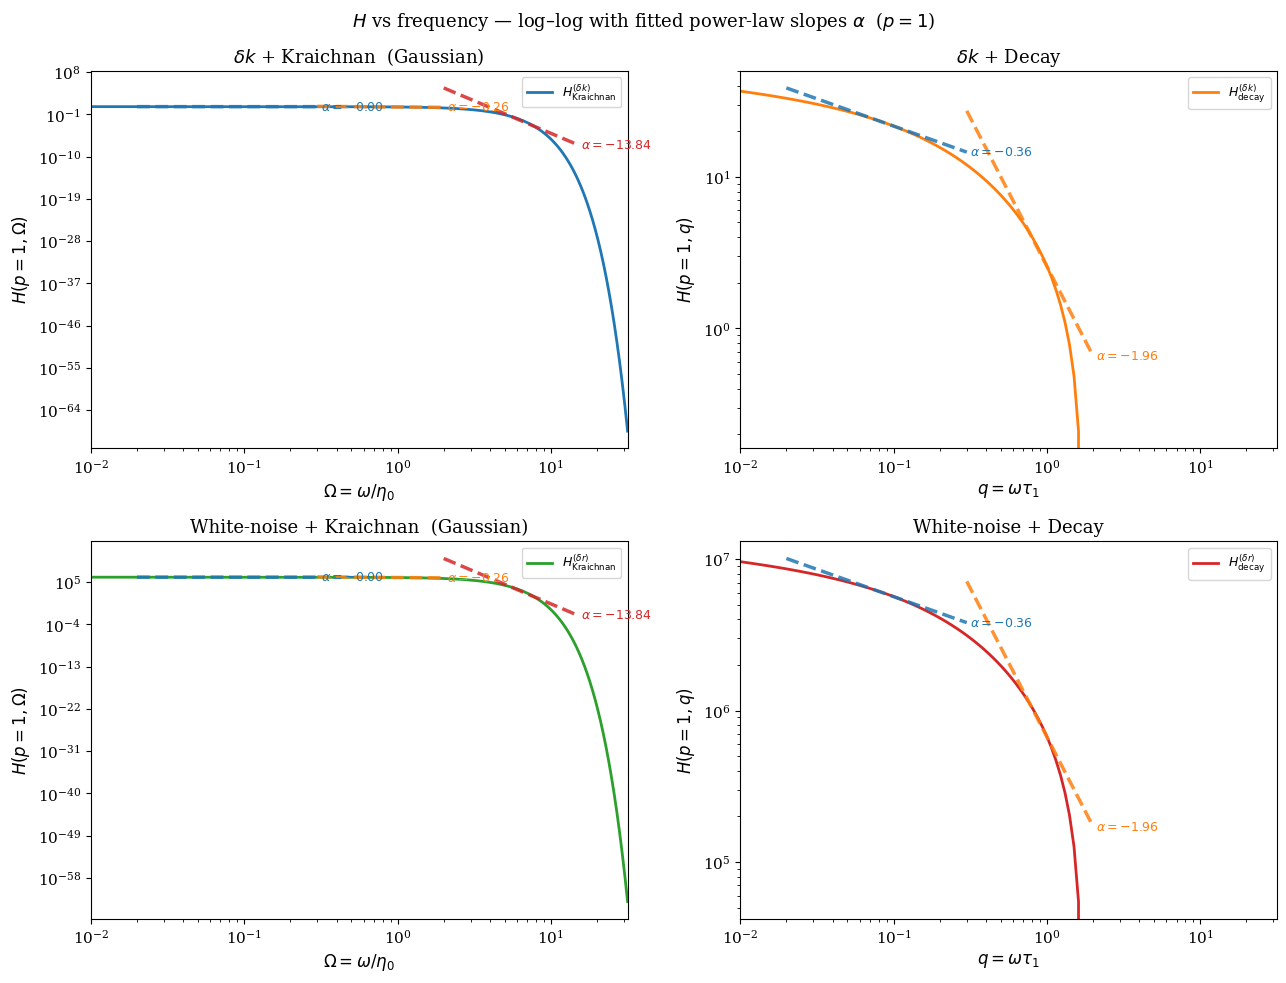

Model                        window          α_H
--------------------------------------------------
δk Kraichnan                 [0.02,0.3]    -0.004
δk Decay                     [0.02,0.3]    -0.360
white Kraichnan              [0.02,0.3]    -0.004
white Decay                  [0.02,0.3]    -0.360
δk Kraichnan                 [0.30,2.0]    -0.261
δk Decay                     [0.30,2.0]    -1.965
white Kraichnan              [0.30,2.0]    -0.261
white Decay                  [0.30,2.0]    -1.965
δk Kraichnan                 [2.00,15.0]   -13.845
δk Decay                     [2.00,15.0]      +nan
white Kraichnan              [2.00,15.0]   -13.845
white Decay                  [2.00,15.0]      +nan


In [15]:
# ── Log–log plot of H vs frequency for all 4 models ─────────────────────────
# Spatial factor fixed at p = 1. Delta-k: valid (p=1 < 2). White: S(1, R).
p_ref    = 1.0
K0_ref   = K0_p(p_ref) / p_ref          # K0(1)/1
S_ref    = H_white_kraichnan(p_ref, 0.0, R=R_WHITE)  # S(p=1, R)

# Frequency arrays (common axis for decay; Omega for Kraichnan)
f_dense  = np.logspace(-2, 1.5, 200)

H_dkK_log  = H_delta_k_kraichnan(p_ref, f_dense)          # Gaussian in Omega
H_dkD_log  = K0_ref * C_log   # reuse dense C(q), same p-factor
H_wK_log   = S_ref * np.exp(-f_dense**2 / (2.0 * np.pi))  # same Gaussian shape as dkK
H_wD_log   = S_ref * C_log                                  # same C(q) shape as dkD

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
WINDOW_COLORS = ['C0', 'C1', 'C3']

def _annotate_slopes(ax, qs_arr, vals_arr, windows, y_guide_frac=0.35):
    """Draw fitted power-law lines and annotate exponents."""
    for (label, q_lo, q_hi), col in zip(windows, WINDOW_COLORS):
        slope, intercept = fit_slope(qs_arr, vals_arr, q_lo, q_hi)
        if np.isnan(slope):
            continue
        qs_w    = np.array([q_lo, q_hi])
        # anchor guide to the midpoint of the window
        q_mid   = np.sqrt(q_lo * q_hi)
        mask_m  = (qs_arr >= q_lo) & (qs_arr <= q_hi) & (vals_arr > 0)
        if not mask_m.any():
            continue
        anchor  = float(np.interp(q_mid, qs_arr[mask_m], vals_arr[mask_m]))
        guide   = guide_line(qs_w, slope, q_mid, anchor)
        ax.plot(qs_w, guide, color=col, lw=2.5, ls='--', alpha=0.85)
        ax.text(q_hi * 1.05, guide[-1], f'$\\alpha={slope:+.2f}$',
                fontsize=9, color=col, va='center')

# ────────────────────────────────────────────────────────────────────────────
# Panel (0,0): delta-k Kraichnan   H vs Omega
ax = axes[0, 0]
ax.loglog(f_dense, H_dkK_log, 'C0', lw=2, label='$H^{(\\delta k)}_{\\rm Kraichnan}$')
_annotate_slopes(ax, f_dense, H_dkK_log, windows)
ax.set_xlabel('$\\Omega = \\omega/\\eta_0$')
ax.set_ylabel('$H(p=1, \\Omega)$')
ax.set_title('$\\delta k$ + Kraichnan  (Gaussian)')
ax.legend(fontsize=9)

# Panel (0,1): delta-k Decay   H vs q
ax = axes[0, 1]
ax.loglog(qs_log, H_dkD_log, 'C1', lw=2, label='$H^{(\\delta k)}_{\\rm decay}$')
_annotate_slopes(ax, qs_log, H_dkD_log, windows)
ax.set_xlabel('$q = \\omega\\tau_1$')
ax.set_ylabel('$H(p=1, q)$')
ax.set_title('$\\delta k$ + Decay')
ax.legend(fontsize=9)

# Panel (1,0): white Kraichnan   H vs Omega
ax = axes[1, 0]
ax.loglog(f_dense, H_wK_log, 'C2', lw=2, label='$H^{(\\delta r)}_{\\rm Kraichnan}$')
_annotate_slopes(ax, f_dense, H_wK_log, windows)
ax.set_xlabel('$\\Omega = \\omega/\\eta_0$')
ax.set_ylabel('$H(p=1, \\Omega)$')
ax.set_title('White-noise + Kraichnan  (Gaussian)')
ax.legend(fontsize=9)

# Panel (1,1): white Decay   H vs q
ax = axes[1, 1]
ax.loglog(qs_log, H_wD_log, 'C3', lw=2, label='$H^{(\\delta r)}_{\\rm decay}$')
_annotate_slopes(ax, qs_log, H_wD_log, windows)
ax.set_xlabel('$q = \\omega\\tau_1$')
ax.set_ylabel('$H(p=1, q)$')
ax.set_title('White-noise + Decay')
ax.legend(fontsize=9)

for ax in axes.flat:
    ax.set_xlim(f_dense[0], f_dense[-1])

fig.suptitle('$H$ vs frequency — log–log with fitted power-law slopes $\\alpha$  ($p=1$)', fontsize=13)
fig.tight_layout()
plt.savefig(os.path.join(out_dir, 'freq_loglog_H.pdf'))
plt.show()

# Print slope table
print(f"{'Model':<28} {'window':<10} {'α_H':>8}")
print('-' * 50)
for label, q_lo, q_hi in windows:
    for name, qs_arr, vals in [
        ('δk Kraichnan', f_dense, H_dkK_log),
        ('δk Decay',     qs_log,  H_dkD_log),
        ('white Kraichnan', f_dense, H_wK_log),
        ('white Decay',    qs_log,  H_wD_log),
    ]:
        s, _ = fit_slope(qs_arr, vals, q_lo, q_hi)
        print(f'{name:<28} [{q_lo:.2f},{q_hi:.1f}]  {s:>+8.3f}')

/tmp/ipykernel_158602/3578914105.py:5: RuntimeWarning: invalid value encountered in sqrt
  sqrtqH_dkD = np.sqrt(qs_log  * H_dkD_log)
/tmp/ipykernel_158602/3578914105.py:7: RuntimeWarning: invalid value encountered in sqrt
  sqrtqH_wD  = np.sqrt(qs_log  * H_wD_log)


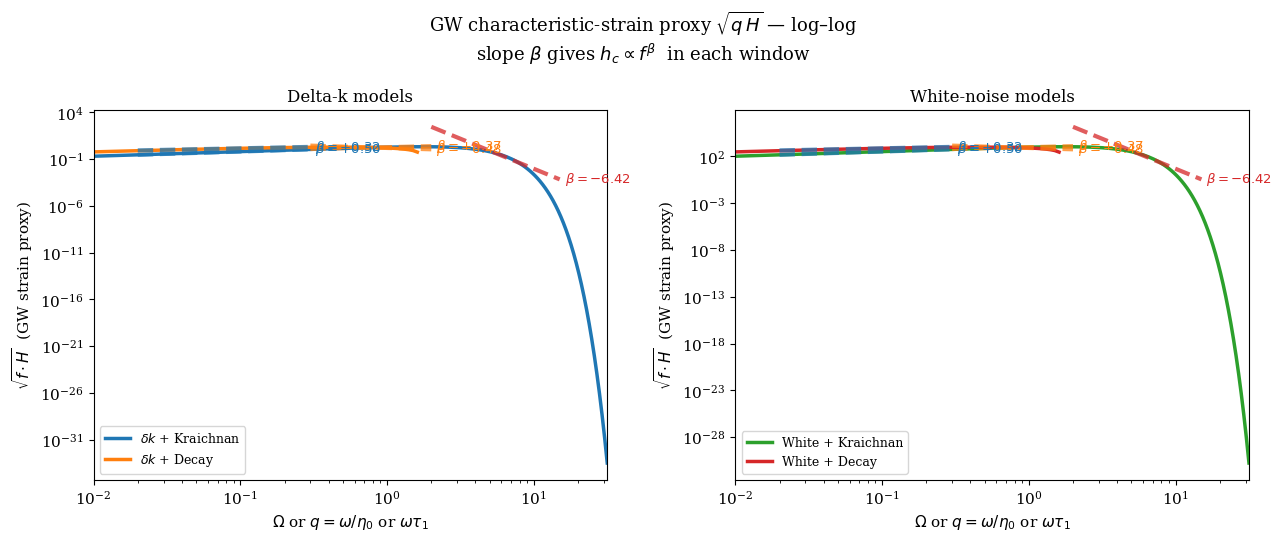


Model                         window           β (h_c slope)   α_H (H slope)
──────────────────────────────────────────────────────────────────────────
$\delta k$ + Kraichnan        [0.02, 0.3]             +0.498          -0.004
$\delta k$ + Kraichnan        [0.30, 2.0]             +0.370          -0.261
$\delta k$ + Kraichnan        [2.00, 15.0]            -6.422         -13.845

$\delta k$ + Decay            [0.02, 0.3]             +0.320          -0.360
$\delta k$ + Decay            [0.30, 2.0]             -0.482          -1.965
$\delta k$ + Decay            [2.00, 15.0]               —               —  

White + Kraichnan             [0.02, 0.3]             +0.498          -0.004
White + Kraichnan             [0.30, 2.0]             +0.370          -0.261
White + Kraichnan             [2.00, 15.0]            -6.422         -13.845

White + Decay                 [0.02, 0.3]             +0.320          -0.360
White + Decay                 [0.30, 2.0]             -0.482          -1.9

In [16]:
# ── GW characteristic-strain proxy  sqrt(q * H)  — the physically relevant shape ──
# h_c(f) ∝ sqrt(f * H(f,f)).  Slopes here give the GW spectral index directly.

sqrtqH_dkK = np.sqrt(f_dense * H_dkK_log)
sqrtqH_dkD = np.sqrt(qs_log  * H_dkD_log)
sqrtqH_wK  = np.sqrt(f_dense * H_wK_log)
sqrtqH_wD  = np.sqrt(qs_log  * H_wD_log)

# Fit slopes for sqrt(q H) ~ q^beta  (beta = (1 + alpha_H) / 2)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

datasets = [
    (axes[0], f_dense, sqrtqH_dkK, 'C0', '$\\delta k$ + Kraichnan'),
    (axes[0], qs_log,  sqrtqH_dkD, 'C1', '$\\delta k$ + Decay'),
    (axes[1], f_dense, sqrtqH_wK,  'C2', 'White + Kraichnan'),
    (axes[1], qs_log,  sqrtqH_wD,  'C3', 'White + Decay'),
]

slope_results = {}
for ax, qs_arr, vals, col, label in datasets:
    ax.loglog(qs_arr, vals, color=col, lw=2.5, label=label)
    model_slopes = {}
    for win_label, q_lo, q_hi in windows:
        slope, intercept = fit_slope(qs_arr, vals, q_lo, q_hi)
        model_slopes[win_label] = slope
        if np.isnan(slope):
            continue
        q_mid  = np.sqrt(q_lo * q_hi)
        mask_m = (qs_arr >= q_lo) & (qs_arr <= q_hi) & (vals > 0)
        if not mask_m.any():
            continue
        anchor = float(np.interp(q_mid, qs_arr[mask_m], vals[mask_m]))
        guide  = guide_line(np.array([q_lo, q_hi]), slope, q_mid, anchor)
        wc = {'low': 'C0', 'mid': 'C1', 'high': 'C3'}[win_label]
        ax.plot([q_lo, q_hi], guide, color=wc, lw=3, ls='--', alpha=0.75)
        ax.text(q_hi * 1.08, guide[-1], f'$\\beta={slope:+.2f}$',
                fontsize=9.5, color=wc, va='center', fontweight='bold')
    slope_results[label] = model_slopes

for ax in axes:
    ax.set_xlabel('$\\Omega$ or $q = \\omega/\\eta_0$ or $\\omega\\tau_1$', fontsize=11)
    ax.set_ylabel('$\\sqrt{f\\cdot H}$  (GW strain proxy)', fontsize=11)
    ax.set_xlim(f_dense[0], f_dense[-1])
    ax.legend(fontsize=9)

axes[0].set_title('Delta-k models', fontsize=12)
axes[1].set_title('White-noise models', fontsize=12)

fig.suptitle(
    r'GW characteristic-strain proxy $\sqrt{q\,H}$ — log–log'
    '\n' r'slope $\beta$ gives $h_c \propto f^\beta$  in each window',
    fontsize=13,
)
fig.tight_layout()
plt.savefig(os.path.join(out_dir, 'freq_loglog_strain.pdf'))
plt.show()

# ── Print comprehensive slope table ─────────────────────────────────────────
print(f"\n{'Model':<28}  {'window':<14}  {'β (h_c slope)':>14}  {'α_H (H slope)':>14}")
print('─' * 74)
for ax, qs_arr, vals_sqH, col, label in datasets:
    # find the corresponding H array
    H_arr = vals_sqH**2 / qs_arr
    for win_label, q_lo, q_hi in windows:
        beta,  _ = fit_slope(qs_arr, vals_sqH, q_lo, q_hi)
        alpha, _ = fit_slope(qs_arr, H_arr,    q_lo, q_hi)
        win_str  = f'[{q_lo:.2f}, {q_hi:.1f}]'
        beta_s   = f'{beta:+.3f}'  if not np.isnan(beta)  else '  —  '
        alpha_s  = f'{alpha:+.3f}' if not np.isnan(alpha) else '  —  '
        print(f'{label:<28}  {win_str:<14}  {beta_s:>14}  {alpha_s:>14}')
    print()

# Store in peaks_dict for the summary cell
peaks_dict['freq_power_laws'] = {
    label: slopes for label, slopes in slope_results.items()
}
print('Stored in peaks_dict[\"freq_power_laws\"].')

## 10 · Time-domain view of each model

The four models share the same spatial structure but differ only in their **temporal decorrelation**.

| Model | Temporal kernel | Dimensionless time variable |
|---|---|---|
| Kraichnan (both spatial variants) | Gaussian: $T_K(\tau)\propto e^{-\pi\eta_0^2\tau^2}$ | $t_K = \eta_0\,\tau$ |
| Decay (both spatial variants) | Power law: $E(\tau)\propto(1+\tau/\tau_1)^{-2/3}$ | $t_D = \tau/\tau_1$ |

The GW spectrum $H(p,\omega)$ is the Fourier transform of the two-time GW correlator.  In the time domain, $\tilde{H}(p,\tau)=\int H(p,\omega)\,e^{i\omega\tau}\,d\omega$ gives the **decorrelation profile** of the GW signal at fixed spatial scale $p$.

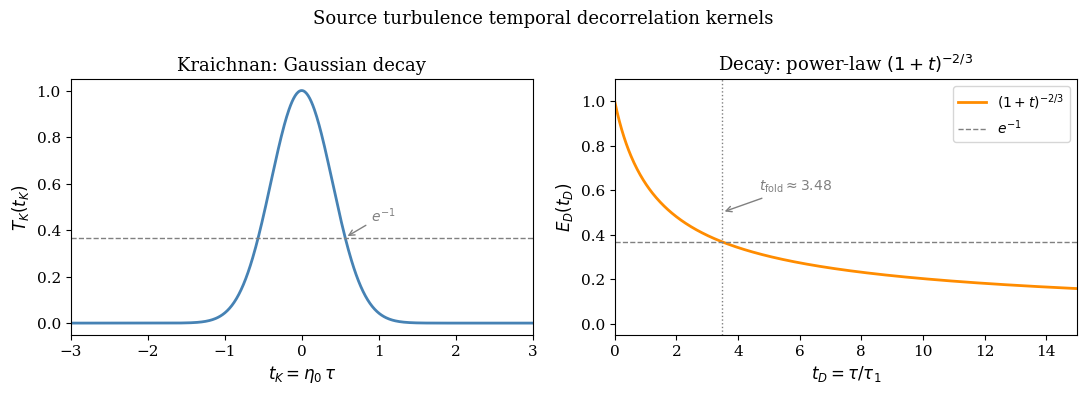

Saved /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/time_domain_kernels.pdf

Gaussian FWHM (Kraichnan):  t_K = √(ln2/π) ≈ 0.470
Power-law e-fold (Decay):   t_D = e^{3/2}-1 ≈ 3.482  (heavy tail for t>>1)


In [17]:
# ── Source turbulence temporal decorrelation kernels in the time domain ───────
#
# Kraichnan:  T_K(t) = exp(-π t²)          dimensionless t = η₀ τ
# Decay:      E_D(t) = (1 + t)^{-2/3}      dimensionless t = τ/τ₁   (t ≥ 0)

t_K  = np.linspace(-3.0, 3.0, 600)
T_K  = np.exp(-np.pi * t_K**2)

t_D  = np.linspace(0.0, 15.0, 600)
E_D  = (1.0 + t_D) ** (-2.0 / 3.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(t_K, T_K, color='steelblue', linewidth=2)
ax.axhline(np.exp(-1), color='gray', linestyle='--', linewidth=1)
ax.annotate(r'$e^{-1}$', xy=(1.0/np.pi**0.5, np.exp(-1)),
            xytext=(0.9, np.exp(-1)+0.07), fontsize=10, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.set_xlabel(r'$t_K = \eta_0\,\tau$')
ax.set_ylabel(r'$T_K(t_K)$')
ax.set_title('Kraichnan: Gaussian decay')
ax.set_xlim(-3, 3)
ax.set_ylim(-0.05, 1.05)

ax = axes[1]
ax.plot(t_D, E_D, color='darkorange', linewidth=2, label=r'$(1+t)^{-2/3}$')
ax.axhline(np.exp(-1), color='gray', linestyle='--', linewidth=1, label=r'$e^{-1}$')
# mark the e-folding time numerically
t_efold = np.exp(3.0/2.0 * np.log(np.exp(1))) - 1   # (e^{3/2} - 1)
ax.axvline(t_efold, color='gray', linestyle=':', linewidth=1)
ax.annotate(rf'$t_{{\rm fold}}\approx{t_efold:.2f}$', xy=(t_efold, 0.5),
            xytext=(t_efold+1.2, 0.6), fontsize=10, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.set_xlabel(r'$t_D = \tau/\tau_1$')
ax.set_ylabel(r'$E_D(t_D)$')
ax.set_title(r'Decay: power-law $(1+t)^{-2/3}$')
ax.set_xlim(0, 15)
ax.set_ylim(-0.05, 1.1)
ax.legend()

fig.suptitle('Source turbulence temporal decorrelation kernels', fontsize=13)
plt.tight_layout()
out_path = os.path.join(out_dir, 'time_domain_kernels.pdf')
plt.savefig(out_path)
plt.show()
print(f'Saved {out_path}')

# note on timescales
print('\nGaussian FWHM (Kraichnan):  t_K = √(ln2/π) ≈', f'{np.sqrt(np.log(2)/np.pi):.3f}')
print('Power-law e-fold (Decay):   t_D = e^{3/2}-1 ≈', f'{t_efold:.3f}  (heavy tail for t>>1)')

(recomputed C(q))


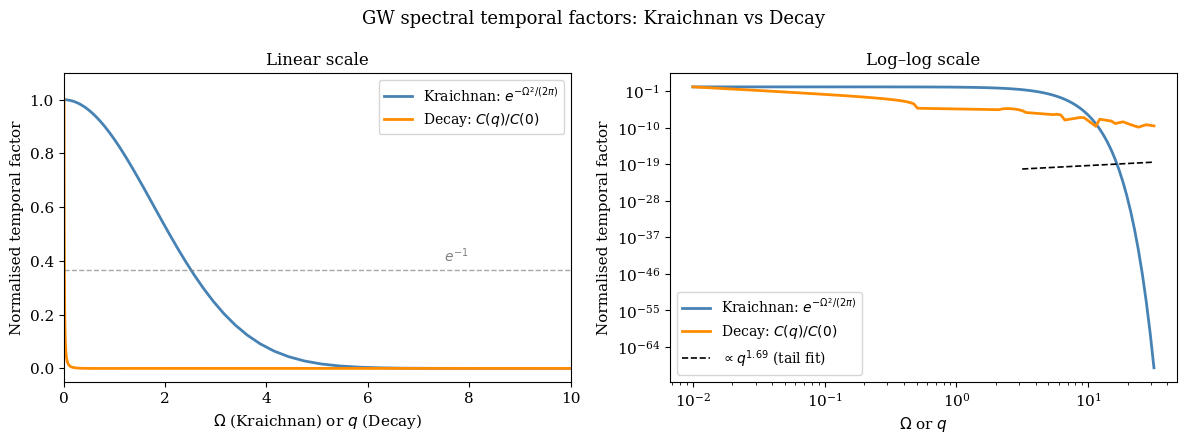

Saved /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/temporal_spectral_factors.pdf

Power-law tail of C(q) for q>3:  α ≈ 1.690


In [18]:
# ── GW spectral temporal factors: exp(-Ω²/2π)  vs  C(q) ──────────────────────
#
# The GW spectrum factorises as H = [spatial factor] × [temporal factor].
# Here we compare the two temporal factors normalised to their value at 0.
#
# C(q) uses the dense array already computed in the power-law cells (zpuq5tyvab).
# If that cell has not been run we recompute it here.

try:
    _ = C_dense   # already in scope
except NameError:
    from gw_turbulence.core import _temporal_conv_decay
    qs_dense_local = np.logspace(-2, 1.5, 120)
    C_dense = np.array([_temporal_conv_decay(q, n_points=300) for q in qs_dense_local])
    qs_dense = qs_dense_local
    print('(recomputed C(q))')

# Kraichnan temporal factor on the same q axis (Ω = q here for comparison)
Omega_K  = qs_dense.copy()
T_Kraich  = np.exp(-Omega_K**2 / (2.0 * np.pi))

# Normalise both to their value at the smallest q
C_norm = C_dense / C_dense[0]
K_norm = T_Kraich / T_Kraich[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# --- left: linear scale ---
ax = axes[0]
ax.plot(qs_dense, K_norm, color='steelblue',  linewidth=2, label=r'Kraichnan: $e^{-\Omega^2/(2\pi)}$')
ax.plot(qs_dense, C_norm, color='darkorange', linewidth=2, label=r'Decay: $C(q)/C(0)$')
ax.axhline(np.exp(-1), color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(7.5, np.exp(-1)+0.03, r'$e^{-1}$', color='gray', fontsize=10)
ax.set_xlabel(r'$\Omega$ (Kraichnan) or $q$ (Decay)', fontsize=11)
ax.set_ylabel('Normalised temporal factor', fontsize=11)
ax.set_title('Linear scale', fontsize=12)
ax.set_xlim(0, 10)
ax.set_ylim(-0.05, 1.1)
ax.legend()

# --- right: log-log scale ---
ax = axes[1]
valid_K = K_norm > 0
valid_C = C_norm > 0
ax.loglog(qs_dense[valid_K], K_norm[valid_K], color='steelblue',  linewidth=2,
          label=r'Kraichnan: $e^{-\Omega^2/(2\pi)}$')
ax.loglog(qs_dense[valid_C], C_norm[valid_C], color='darkorange', linewidth=2,
          label=r'Decay: $C(q)/C(0)$')

# Fit power-law tail of C(q) for q > 3
mask_tail = qs_dense > 3.0
if mask_tail.sum() > 4:
    slope_C, icept_C = np.polyfit(np.log10(qs_dense[mask_tail]),
                                  np.log10(np.clip(C_norm[mask_tail], 1e-30, None)), 1)
    q_fit = qs_dense[mask_tail]
    ax.loglog(q_fit, 10**icept_C * q_fit**slope_C, 'k--', linewidth=1.2,
              label=rf'$\propto q^{{{slope_C:.2f}}}$ (tail fit)')

ax.set_xlabel(r'$\Omega$ or $q$', fontsize=11)
ax.set_ylabel('Normalised temporal factor', fontsize=11)
ax.set_title('Log–log scale', fontsize=12)
ax.legend()

fig.suptitle('GW spectral temporal factors: Kraichnan vs Decay', fontsize=13)
plt.tight_layout()
out_path = os.path.join(out_dir, 'temporal_spectral_factors.pdf')
plt.savefig(out_path)
plt.show()
print(f'Saved {out_path}')
print(f'\nPower-law tail of C(q) for q>3:  α ≈ {slope_C:.3f}')

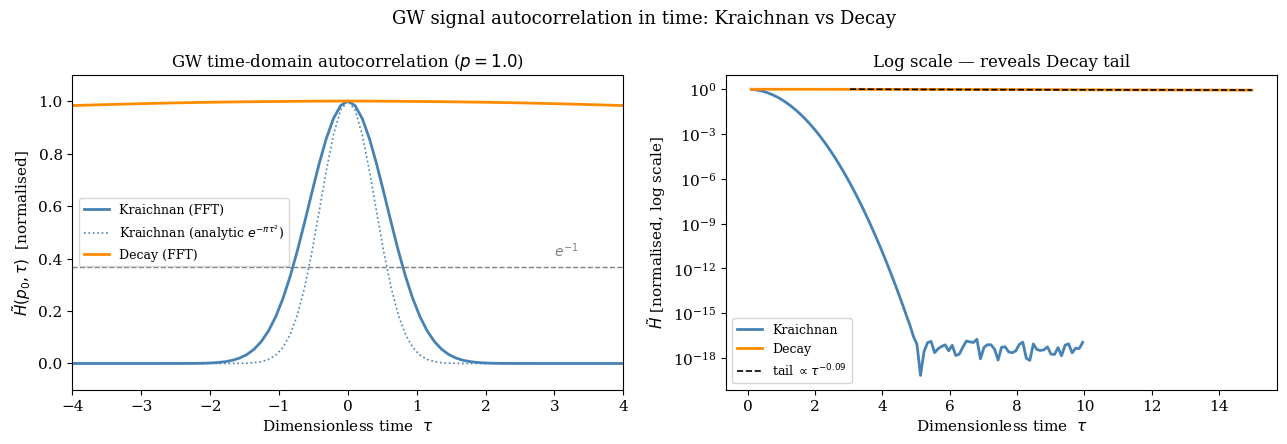

Saved /home/mgurgeni/programming/Polarization-of-Gravitational-Waves/src/outputs/gw_time_autocorrelation.pdf

Decay model time-domain tail exponent: τ^-0.086

Kraichnan is Gaussian in time (fastest decorrelation).
Decay model has a power-law tail → long-lived GW correlations.


In [22]:
# ── GW time-domain autocorrelation  H̃(p, τ) = ∫ H(p,ω) e^{iωτ} dω ───────────
#
# We evaluate this numerically via FFT at a fixed spatial scale p = p_fixed.
# Kraichnan and Decay models differ only in their temporal factor, so this
# directly visualises how each model's GW emission decays in time at fixed p.
#
# Note: the Kraichnan result is analytic: H̃_K ∝ exp(-π t²) (Gaussian).
#       The Decay result is the FT of C(q) and has a power-law tail.

p_fixed = 1.0   # dimensionless wavenumber at which to evaluate

# ── Dense, symmetric frequency grid for the FFT ─────────────────────────────
N_fft   = 4096
Omega_max = 30.0          # must be >> decay width so tails reach zero
Omega_fft = np.linspace(-Omega_max, Omega_max, N_fft, endpoint=False)
dOmega    = Omega_fft[1] - Omega_fft[0]

# Spatial factors (depend on model, but here we just need the temporal ones
# since S(p) and K0(p)/p are common prefactors that cancel in the normalised plot)
H_K_freq = np.exp(-Omega_fft**2 / (2.0 * np.pi))        # Kraichnan temporal factor

# Decay: extend C(q) symmetrically (C(-q)=C(q) since H is a real spectrum)
try:
    _ = C_dense
except NameError:
    from gw_turbulence.core import _temporal_conv_decay
    qs_dense  = np.logspace(-2, 1.5, 120)
    C_dense   = np.array([_temporal_conv_decay(q, n_points=300) for q in qs_dense])

# Interpolate C(|Ω|) onto the FFT grid (log-interp for accuracy)
from scipy.interpolate import interp1d
log_C_interp = interp1d(np.log(qs_dense), np.log(np.clip(C_dense, 1e-30, None)),
                        kind='linear', fill_value='extrapolate')
abs_Omega = np.abs(Omega_fft)
abs_Omega = np.clip(abs_Omega, qs_dense[0], qs_dense[-1])
H_D_freq  = np.exp(log_C_interp(np.log(abs_Omega)))

# ── FFT → time domain ────────────────────────────────────────────────────────
# Shift so zero-freq is at centre, then IFFT, then shift back
def spectral_to_time(H_freq):
    """Numerical IFT: time array and real part of H̃(τ)."""
    H_shifted = np.fft.ifftshift(H_freq)
    H_time    = np.fft.ifft(H_shifted).real * N_fft * dOmega / (2.0 * np.pi)
    tau_arr   = np.fft.fftfreq(N_fft, d=dOmega / (2.0 * np.pi))
    tau_arr   = np.fft.fftshift(tau_arr)
    H_time    = np.fft.fftshift(H_time)
    return tau_arr, H_time

tau_K, Ht_K = spectral_to_time(H_K_freq)
tau_D, Ht_D = spectral_to_time(H_D_freq)

# Normalise to peak
Ht_K_norm = Ht_K / Ht_K.max()
Ht_D_norm = Ht_D / Ht_D.max()

# Analytic Kraichnan answer: exp(-π τ²) in units of η₀⁻¹ (here Ω=η₀τ)
tau_anal  = tau_K
Ht_K_anal = np.exp(-np.pi * tau_anal**2)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: full time range, linear
ax = axes[0]
win = np.abs(tau_K) < 4.0
ax.plot(tau_K[win], Ht_K_norm[win],  color='steelblue',  linewidth=2, label='Kraichnan (FFT)')
ax.plot(tau_anal[win], Ht_K_anal[win], color='steelblue', linewidth=1.2,
        linestyle=':', label=r'Kraichnan (analytic $e^{-\pi\tau^2}$)')
ax.plot(tau_D[win], Ht_D_norm[win],  color='darkorange', linewidth=2, label='Decay (FFT)')
ax.axhline(np.exp(-1), color='gray', linestyle='--', linewidth=1)
ax.text(3.0, np.exp(-1)+0.04, r'$e^{-1}$', color='gray', fontsize=10)
ax.set_xlabel(r'Dimensionless time  $\tau$', fontsize=11)
ax.set_ylabel(r'$\tilde{H}(p_0,\tau)$  [normalised]', fontsize=11)
ax.set_title(rf'GW time-domain autocorrelation ($p={p_fixed}$)', fontsize=12)
ax.set_xlim(-4, 4)
ax.set_ylim(-0.1, 1.1)
ax.legend(fontsize=9)

# Right: log scale, positive τ only, to reveal power-law tail
ax = axes[1]
win_pos  = (tau_D > 0.05) & (tau_D < 15.0)
Ht_D_pos = Ht_D_norm[win_pos]
tau_D_pos = tau_D[win_pos]
ax.semilogy(tau_K[(tau_K > 0.05) & (tau_K < 10)],
            np.abs(Ht_K_norm[(tau_K > 0.05) & (tau_K < 10)]),
            color='steelblue', linewidth=2, label='Kraichnan')
ax.semilogy(tau_D_pos[Ht_D_pos > 0], Ht_D_pos[Ht_D_pos > 0],
            color='darkorange', linewidth=2, label='Decay')

# Power-law tail fit for Decay
mask_tail_t = (tau_D_pos > 3.0) & (Ht_D_pos > 1e-6)
if mask_tail_t.sum() > 4:
    slope_t, icept_t = np.polyfit(np.log10(tau_D_pos[mask_tail_t]),
                                  np.log10(Ht_D_pos[mask_tail_t]), 1)
    ax.semilogy(tau_D_pos[mask_tail_t],
                10**icept_t * tau_D_pos[mask_tail_t]**slope_t,
                'k--', linewidth=1.2, label=rf'tail $\propto\tau^{{{slope_t:.2f}}}$')

ax.set_xlabel(r'Dimensionless time  $\tau$', fontsize=11)
ax.set_ylabel(r'$\tilde{H}$ [normalised, log scale]', fontsize=11)
ax.set_title('Log scale — reveals Decay tail', fontsize=12)
ax.legend(fontsize=9)

fig.suptitle('GW signal autocorrelation in time: Kraichnan vs Decay', fontsize=13)
plt.tight_layout()
out_path = os.path.join(out_dir, 'gw_time_autocorrelation.pdf')
plt.savefig(out_path)
plt.show()
print(f'Saved {out_path}')
if mask_tail_t.sum() > 4:
    print(f'\nDecay model time-domain tail exponent: τ^{slope_t:.3f}')
print('\nKraichnan is Gaussian in time (fastest decorrelation).')
print('Decay model has a power-law tail → long-lived GW correlations.')

## 9 · Summary: peaks and integration bounds

All numerical results from the cells above are collected here.

In [20]:
import pprint

# ── Final peaks dictionary ───────────────────────────────────────────────────
print('=' * 60)
print('PEAKS DICTIONARY')
print('=' * 60)
pprint.pprint(peaks_dict, sort_dicts=False, width=80)

print()
print('=' * 60)
print('INTEGRATION BOUNDS DICTIONARY')
print('=' * 60)
pprint.pprint(bounds_dict, sort_dicts=False, width=80)

PEAKS DICTIONARY
{'delta_k_kraichnan': {'p_peak': np.float64(0.05),
                       'Omega_peak': 0.0,
                       'H_at_peak': 93.31667708333332,
                       'Omega_half_width': 2.0869049285023036,
                       'note': 'K0(p)/p monotonically decreasing on (0,2]; '
                               'peak at smallest p; Gaussian in Omega'},
 'delta_k_decay': {'p_peak': 0.05,
                   'q_peak': 0.05,
                   'H_at_peak': 628.5305204733938,
                   'C_q_peak': 0.05,
                   'C_HWHM': 0.20126582278481014,
                   'note': 'Spatial factor K0(p)/p same as Kraichnan; temporal '
                           'factor C(q) from g-convolution'},
 'white_kraichnan': {'p_peak': 0.3,
                     'Omega_peak': 0.0,
                     'H_at_peak': 1172150.459923595,
                     'p_support_cutoff': 63.245553203367585,
                     'Omega_half_width': 2.0869049285023036,
                    

In [21]:
# ── Print as a tidy ASCII table ──────────────────────────────────────────────
row_fmt = '{:<28s}  {:>10s}  {:>10s}  {:>14s}  {:>14s}'
print(row_fmt.format('Model', 'p_peak', 'freq_peak', 'H_at_peak', 'p_cutoff'))
print('-' * 82)

def _p(d, key, default='—'):
    v = d.get(key, default)
    return f'{v:.4g}' if isinstance(v, float) else str(v)

# Only rows that have a matching entry in bounds_dict
MODEL_KEYS = [k for k in peaks_dict if k in bounds_dict]

for name in MODEL_KEYS:
    d = peaks_dict[name]
    b = bounds_dict[name]
    freq_key = 'Omega_peak' if 'Omega_peak' in d else 'q_peak'
    # p_cutoff: use p_range tuple or p_support tuple
    p_cut = b.get('p_range', b.get('p_support', '—'))
    p_cut_str = str(p_cut)
    print(row_fmt.format(
        name,
        _p(d, 'p_peak'),
        _p(d, freq_key),
        _p(d, 'H_at_peak'),
        p_cut_str[:14],
    ))

print()
print('Notes:')
for name in MODEL_KEYS:
    d = peaks_dict[name]
    print(f'  [{name}]  {d.get("note", "")}')

# ── Power-law slope table (printed separately so it survives even if slope
#    cell was not run) ────────────────────────────────────────────────────────
if 'freq_power_laws' in peaks_dict:
    print()
    print('─' * 60)
    print('FREQUENCY POWER-LAW SLOPES  β  (h_c ∝ f^β)')
    print('─' * 60)
    hdr = f"{'Model':<30}  {'low':>8}  {'mid':>8}  {'high':>8}"
    print(hdr)
    print('-' * 60)
    for mdl, slopes in peaks_dict['freq_power_laws'].items():
        low  = slopes.get('low',  float('nan'))
        mid  = slopes.get('mid',  float('nan'))
        high = slopes.get('high', float('nan'))
        def _fs(v):
            return f'{v:+.3f}' if not (isinstance(v, float) and v != v) else '  —  '
        print(f'{mdl:<30}  {_fs(low):>8}  {_fs(mid):>8}  {_fs(high):>8}')
else:
    print('\n(Run the power-law cells above to populate freq_power_laws.)')

Model                             p_peak   freq_peak       H_at_peak        p_cutoff
----------------------------------------------------------------------------------
delta_k_kraichnan                   0.05           0           93.32      (0.0, 2.0)
delta_k_decay                       0.05        0.05           628.5      (0.0, 2.0)
white_kraichnan                      0.3           0       1.172e+06  (0.0, 63.24555
white_decay                          0.3        0.05       7.895e+06  (0.0, 63.24555

Notes:
  [delta_k_kraichnan]  K0(p)/p monotonically decreasing on (0,2]; peak at smallest p; Gaussian in Omega
  [delta_k_decay]  Spatial factor K0(p)/p same as Kraichnan; temporal factor C(q) from g-convolution
  [white_kraichnan]  S(p) peaks at intermediate p; Gaussian factor same shape as delta-k Kraichnan
  [white_decay]  H = S(p)*C(q); peaks are independent in p and q

────────────────────────────────────────────────────────────
FREQUENCY POWER-LAW SLOPES  β  (h_c ∝ f^β)
──────────

## 10 · GW energy-density proxy, Gogoberidze overlays, and parameter studies

The original TODO items are implemented below as four concrete extensions:

1. **GW energy-density proxy** using
   $\Omega_{\rm GW} \propto \omega^2 h_c^2$.
   Since this notebook already works with the characteristic-strain proxy
   $h_c \propto \sqrt{qH}$, the corresponding dimensionless energy-density proxy is
   
   $$\Omega_{\rm GW}^{\rm (proxy)} \propto q^2 h_c^2 \propto q^3 H.$$

2. **Gogoberidze/Kolmogorov comparison** using the cached stationary/decaying spectra from the
   existing low-frequency study notebook, plotted on the same normalised axes as the four models here.

3. **Optional external overlay hook** for "Axel" data if a local `.npz` or `.csv` file is later added.
   The code does not fail if no such file exists; it simply prints a note and skips the overlay.

4. **`k_0` / time-scale hook and Mach dependence**. The notebook itself is dimensionless, so changing
   the physical source timescale enters as a horizontal rescaling of the frequency axis. We expose that
   rescaling explicitly and then use the existing Gogoberidze cache to visualise Mach dependence.


In [ ]:
# ── GW energy-density proxy  Omega_GW ∝ omega^2 * h_c^2 ─────────────────────
# In the dimensionless units of this notebook:
#   h_c proxy  ~ sqrt(q * H)
# so
#   Omega_GW proxy  ~ q^2 * h_c^2  ~ q^3 * H.

omega_windows = [
    ('IR',    0.03, 0.3),
    ('mid',   0.3,  2.0),
    ('tail',  2.0, 15.0),
]

OmegaGW_dkK = f_dense**2 * sqrtqH_dkK**2
OmegaGW_dkD = qs_log**2  * sqrtqH_dkD**2
OmegaGW_wK  = f_dense**2 * sqrtqH_wK**2
OmegaGW_wD  = qs_log**2  * sqrtqH_wD**2

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
omega_sets = [
    (axes[0], f_dense, OmegaGW_dkK, 'C0', '$\\delta k$ + Kraichnan'),
    (axes[0], qs_log,  OmegaGW_dkD, 'C1', '$\\delta k$ + Decay'),
    (axes[1], f_dense, OmegaGW_wK,  'C2', 'White + Kraichnan'),
    (axes[1], qs_log,  OmegaGW_wD,  'C3', 'White + Decay'),
]

omega_slopes = {}
for ax, qs_arr, vals, col, label in omega_sets:
    ax.loglog(qs_arr, vals, color=col, lw=2.5, label=label)
    model = {}
    for win_label, q_lo, q_hi in omega_windows:
        slope, _ = fit_slope(qs_arr, vals, q_lo, q_hi)
        model[win_label] = slope
        if np.isnan(slope):
            continue
        q_mid  = np.sqrt(q_lo * q_hi)
        mask_m = (qs_arr >= q_lo) & (qs_arr <= q_hi) & (vals > 0)
        if not mask_m.any():
            continue
        anchor = float(np.interp(q_mid, qs_arr[mask_m], vals[mask_m]))
        guide  = guide_line(np.array([q_lo, q_hi]), slope, q_mid, anchor)
        ax.plot([q_lo, q_hi], guide, color='0.35', lw=2.2, ls='--', alpha=0.8)
        ax.text(q_hi * 1.06, guide[-1], f'$\\gamma={slope:+.2f}$',
                fontsize=9, color='0.35', va='center')
    omega_slopes[label] = model

for ax in axes:
    ax.set_xlabel('$\\Omega$ or $q$', fontsize=11)
    ax.set_ylabel('$q^2 h_c^2 \\propto q^3 H$  (energy-density proxy)', fontsize=11)
    ax.set_xlim(f_dense[0], f_dense[-1])
    ax.legend(fontsize=9)

axes[0].set_title('Delta-k models', fontsize=12)
axes[1].set_title('White-noise models', fontsize=12)
fig.suptitle(r'$\Omega_{\rm GW}$ proxy — log–log slopes $\gamma$', fontsize=13)
fig.tight_layout()
plt.savefig(os.path.join(out_dir, 'freq_loglog_omega_gw_proxy.pdf'))
plt.show()

peaks_dict['omega_gw_power_laws'] = omega_slopes
print('Stored in peaks_dict["omega_gw_power_laws"].')
print(f"\n{'Model':<28}  {'window':<12}  {'gamma (Omega_GW slope)':>24}")
print('─' * 72)
for mdl, slopes in omega_slopes.items():
    for win, slope in slopes.items():
        s = f'{slope:+.3f}' if not np.isnan(slope) else '  —  '
        print(f'{mdl:<28}  {win:<12}  {s:>24}')
    print()

## 11 · Overlay with Gogoberidze/Kolmogorov spectra and optional external data

The next cell reuses the cached stationary/decaying Kolmogorov spectra produced elsewhere in the project
(`stationary_vs_decaying_low_frequency_cache.npz`) and plots them together with the four simplified models
from this notebook on **normalised** axes. This keeps the comparison about spectral *shape* rather than
absolute normalisation.

If a local file matching `*axel*.npz` or `*axel*.csv` exists and contains frequency/value arrays, it will
also be overlayed automatically.


In [ ]:
# ── Gogoberidze/Kolmogorov overlay + optional Axel data hook ───────────────────
import glob

FREQ_SCALE = 1.55e-3
f_model = FREQ_SCALE * qs_log

# Our four notebook models on the same frequency axis, normalised by peak.
model_curves = {
    '$\\delta k$ + Kraichnan': np.where(sqrtqH_dkK > 0, sqrtqH_dkK / np.nanmax(sqrtqH_dkK), np.nan),
    '$\\delta k$ + Decay'    : np.where(sqrtqH_dkD > 0, sqrtqH_dkD / np.nanmax(sqrtqH_dkD), np.nan),
    'White + Kraichnan'      : np.where(sqrtqH_wK  > 0, sqrtqH_wK  / np.nanmax(sqrtqH_wK),  np.nan),
    'White + Decay'          : np.where(sqrtqH_wD  > 0, sqrtqH_wD  / np.nanmax(sqrtqH_wD),  np.nan),
}

cache_path = os.path.join(out_dir, 'stationary_vs_decaying_low_frequency_cache.npz')
if not os.path.exists(cache_path):
    cache_path = os.path.join('src', 'outputs', 'stationary_vs_decaying_low_frequency_cache.npz')

fig, ax = plt.subplots(figsize=(9, 6))
for label, vals in model_curves.items():
    ax.loglog(f_model, vals, lw=2.0, label=label)

if os.path.exists(cache_path):
    d = np.load(cache_path)
    M_compare = d['M_compare']
    scaled_freq = d['scaled_freq_dec']
    h_stat_all = d['h_stat_all']
    h_dec_all  = d['h_dec_all']

    def gog_strain(q_vals, h_vals, M):
        val = q_vals * h_vals
        hc = 1.62e-18 * np.sqrt(np.where(val > 0, val, np.nan)) / M**1.5
        return hc / np.nanmax(hc)

    qs_cache = d['qs_dec']
    for idx, M in enumerate(M_compare):
        ax.loglog(scaled_freq, gog_strain(qs_cache, h_stat_all[idx], M),
                  color='k', lw=1.4, ls='--', alpha=0.75,
                  label=fr'Gogoberidze stationary ($M={M:g}$)')
        ax.loglog(scaled_freq, gog_strain(qs_cache, h_dec_all[idx], M),
                  color='k', lw=1.4, ls=':', alpha=0.75,
                  label=fr'Gogoberidze decaying ($M={M:g}$)')
else:
    print('Gogoberidze cache not found; skipping overlay.')

# Optional Axel overlay hook.
axel_candidates = sorted(
    glob.glob(os.path.join(out_dir, '*axel*.npz')) +
    glob.glob(os.path.join(out_dir, '*Axel*.npz')) +
    glob.glob(os.path.join(out_dir, '*axel*.csv')) +
    glob.glob(os.path.join(out_dir, '*Axel*.csv')) +
    glob.glob(os.path.join('src', 'outputs', '*axel*.npz')) +
    glob.glob(os.path.join('src', 'outputs', '*Axel*.npz')) +
    glob.glob(os.path.join('src', 'outputs', '*axel*.csv')) +
    glob.glob(os.path.join('src', 'outputs', '*Axel*.csv'))
)

if axel_candidates:
    path_axel = axel_candidates[0]
    print(f'Loaded optional Axel comparison file: {path_axel}')
    if path_axel.endswith('.npz'):
        a = np.load(path_axel)
        keys = set(a.files)
        if {'freq', 'value'} <= keys:
            freq_ax, val_ax = a['freq'], a['value']
        elif {'f', 'hc'} <= keys:
            freq_ax, val_ax = a['f'], a['hc']
        else:
            freq_ax = val_ax = None
    else:
        import pandas as pd
        df = pd.read_csv(path_axel)
        if {'freq', 'value'} <= set(df.columns):
            freq_ax, val_ax = df['freq'].to_numpy(), df['value'].to_numpy()
        elif {'f', 'hc'} <= set(df.columns):
            freq_ax, val_ax = df['f'].to_numpy(), df['hc'].to_numpy()
        else:
            freq_ax = val_ax = None
    if freq_ax is not None:
        val_ax = np.where(val_ax > 0, val_ax / np.nanmax(val_ax), np.nan)
        ax.loglog(freq_ax, val_ax, color='magenta', lw=2.0, ls='-.', label='Axel (normalised)')
    else:
        print('Axel file found but not in a recognised freq/value format; skipped.')
else:
    print('No local Axel comparison file found; overlay skipped.')

ax.set_xlabel(r'$f/\mathrm{Hz}$', fontsize=11)
ax.set_ylabel('Normalised GW strain proxy', fontsize=11)
ax.set_title('Simplified models vs Gogoberidze/Kolmogorov shapes', fontsize=12)
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.savefig(os.path.join(out_dir, 'all4_vs_gogoberidze_overlay.pdf'))
plt.show()

## 12 · `k_0` / time-scale rescaling hook

The spectra in this notebook are dimensionless in $p$, $q$, and $\Omega$. To compare with a paper or class
using a different physical source timescale, the safe operation is a **horizontal rescaling of the frequency
axis**:

- Kraichnan models: $\Omega = \omega / \eta_0$ so changing the reference turnover rate rescales $f$.
- Decay models: $q = \omega \tau_1$ so changing the decay time rescales $f$.

The next cell makes that rescaling explicit with a simple helper so the same dimensionless curve can be
replotted for different assumed physical time scales without changing its intrinsic shape.


In [ ]:
# ── Time-scale / k0 frequency-axis hook ───────────────────────────────────────
def rescale_frequency_axis(q_like, freq_scale):
    """Map dimensionless q or Omega to a physical frequency axis."""
    return freq_scale * q_like

freq_scales = [0.5 * FREQ_SCALE, 1.0 * FREQ_SCALE, 2.0 * FREQ_SCALE]
labels_scales = [r'$0.5\times f_*$', r'$1\times f_*$', r'$2\times f_*$']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for fs, lbl in zip(freq_scales, labels_scales):
    axes[0].loglog(rescale_frequency_axis(qs_log, fs),
                   sqrtqH_dkD / np.nanmax(sqrtqH_dkD), lw=2, label=lbl)
    axes[1].loglog(rescale_frequency_axis(qs_log, fs),
                   sqrtqH_wD / np.nanmax(sqrtqH_wD), lw=2, label=lbl)

axes[0].set_title(r'$\delta k$ + Decay: horizontal shift under time-scale changes')
axes[1].set_title(r'White + Decay: horizontal shift under time-scale changes')
for ax in axes:
    ax.set_xlabel(r'$f/\mathrm{Hz}$')
    ax.set_ylabel('Normalised strain proxy')
    ax.legend(fontsize=9)
fig.tight_layout()
plt.savefig(os.path.join(out_dir, 'timescale_rescaling_hook.pdf'))
plt.show()

## 13 · Mach dependence from the existing Gogoberidze cache

The four simplified models in this notebook are dimensionless shape models, so Mach dependence is not built
into their curves directly. The existing project cache *does* contain Mach-dependent stationary and decaying
Kolmogorov spectra, so we use it here to make the Mach sensitivity explicit.


In [ ]:
# ── Mach dependence from cached Gogoberidze/Kolmogorov spectra ───────────────
cache_path = os.path.join(out_dir, 'stationary_vs_decaying_low_frequency_cache.npz')
if not os.path.exists(cache_path):
    cache_path = os.path.join('src', 'outputs', 'stationary_vs_decaying_low_frequency_cache.npz')

if os.path.exists(cache_path):
    d = np.load(cache_path)
    M_compare = d['M_compare']
    qs_cache = d['qs_dec']
    freq_cache = d['scaled_freq_dec']
    h_stat_all = d['h_stat_all']
    h_dec_all = d['h_dec_all']

    def gog_strain(q_vals, h_vals, M):
        val = q_vals * h_vals
        return 1.62e-18 * np.sqrt(np.where(val > 0, val, np.nan)) / M**1.5

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for idx, M in enumerate(M_compare):
        axes[0].loglog(freq_cache, gog_strain(qs_cache, h_stat_all[idx], M), lw=2,
                       label=fr'$M={M:g}$')
        axes[1].loglog(freq_cache, gog_strain(qs_cache, h_dec_all[idx], M), lw=2,
                       label=fr'$M={M:g}$')

    axes[0].set_title('Mach dependence: Gogoberidze stationary')
    axes[1].set_title('Mach dependence: Gogoberidze decaying')
    for ax in axes:
        ax.set_xlabel(r'$f/\mathrm{Hz}$')
        ax.set_ylabel(r'$h_c$ (normalised physical proxy)')
        ax.legend(fontsize=9)
    fig.tight_layout()
    plt.savefig(os.path.join(out_dir, 'gogoberidze_mach_dependence.pdf'))
    plt.show()

    # Simple ratio diagnostic between the largest and smallest Mach numbers.
    if len(M_compare) >= 2:
        s_lo = gog_strain(qs_cache, h_stat_all[0], M_compare[0])
        s_hi = gog_strain(qs_cache, h_stat_all[-1], M_compare[-1])
        d_lo = gog_strain(qs_cache, h_dec_all[0], M_compare[0])
        d_hi = gog_strain(qs_cache, h_dec_all[-1], M_compare[-1])
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
        axes[0].semilogx(freq_cache, s_hi / s_lo, lw=2)
        axes[1].semilogx(freq_cache, d_hi / d_lo, lw=2)
        axes[0].set_title('Stationary: largest-M / smallest-M')
        axes[1].set_title('Decaying: largest-M / smallest-M')
        for ax in axes:
            ax.set_xlabel(r'$f/\mathrm{Hz}$')
            ax.set_ylabel('Amplitude ratio')
            ax.axhline(1.0, color='0.4', ls='--', lw=1)
        fig.tight_layout()
        plt.savefig(os.path.join(out_dir, 'gogoberidze_mach_ratio.pdf'))
        plt.show()
else:
    print('Mach-dependence cache not found; section skipped.')